# 基于任务下发前特征的任务时间与能耗预测

本 Notebook 使用最新版 `build_task_features_v7_累计升降.py` 生成的任务特征 JSON，预测两个目标：

- **任务时间**：`task_duration_min`，单位为分钟，直接读取任务特征 JSON 中的标签；
- **任务能耗**：`total_energy_soc_delta_pct`，单位为 SOC 百分点。

默认使用 18 个任务下发时可获得的特征，覆盖：

- 起终点距离、规划路线距离和海拔净变化；
- 规划路径坡度均值、坡度标准差、累计上升和累计下降；
- 同车历史速度与历史时长；
- 单条及前 3 条相似 OD 历史任务统计；
- 当前任务开始前 30 分钟的全车队速度状态。

比较模型：

- 规划距离比例 Baseline；
- 线性回归；
- XGBoost；
- 线性回归 + XGBoost 残差；
- LightGBM；
- HistGradientBoostingRegressor（HGBR）；
- 随机森林。

每个模型都会分别绘制：

1. 任务时间真实值与预测值；
2. 任务时间残差；
3. 任务能耗真实值与预测值；
4. 任务能耗残差。

> 数据按 `actual_start_time` 排序，使用较早任务训练、较晚任务测试；网格搜索使用 `TimeSeriesSplit`，不随机打乱时间顺序。


### 线性回归 + XGBoost残差

该组合模型先用线性回归学习距离、历史任务时长等主要连续趋势，
再让 XGBoost 学习线性模型没有解释的非线性残差：

```text
最终预测 = 线性回归预测 + XGBoost残差预测
```

残差训练标签使用 `TimeSeriesSplit` 生成的线性回归 OOF 预测计算，
避免直接使用线性模型在自身训练样本上的拟合残差。


## 1. 安装与导入依赖

首次运行前可在终端执行：

```bash
pip install pandas numpy matplotlib scikit-learn xgboost lightgbm joblib
```

Windows 上如果 joblib 无法识别物理核心数，下面会通过 `LOKY_MAX_CPU_COUNT` 限制并行核心数。


In [1]:
import os

# 必须在导入 sklearn / joblib 前设置
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

print("依赖导入完成。")


依赖导入完成。


## 2. 配置文件路径、特征和训练参数

通常只需要修改 `DATA_FILE` 和 `OUTPUT_DIR`。

默认假设 Notebook 与 JSON 文件位于同一目录。


In [2]:
# =========================
# 1. 文件路径
# =========================

# 特征 JSON 所在目录
DATA_FILE = Path(r"C:\Users\14993\PycharmProjects\BoLei-DataMining\data\任务特征和标签_20米.json")

# 模型和结果保存目录
OUTPUT_DIR = Path(r"C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults_PreTaskFeatures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 核心特征
# =========================

CORE_FEATURE_COLS = [
    "straight_line_distance_m",
    "planned_total_distance_m",
    "endpoint_altitude_change_m",
    "planned_slope_mean",
    "planned_slope_std",
    "planned_cumulative_ascent_m",
    "planned_cumulative_descent_m",

    "vehicle_prev1_duration_sec",

    "similar_task_actual_distance_km",
    "similar_task_duration_min",
    "similar_task_energy_soc_delta_pct",
    "similar_top3_duration_mean_sec",
    "similar_top3_od_distance_mean_m",

    "fleet_prev60m_speed_mean",
    "fleet_prev60m_speed_min",
]
# 这些辅助字段同样在任务开始前可获得，但默认不加入模型。
# 改为 True 后，可以检查它们是否能进一步提高性能。
USE_QUALITY_FEATURES = False

QUALITY_FEATURE_COLS = [
    "vehicle_prev5_task_count",
    "similar_task_od_distance_m",
    "similar_task_time_gap_min",
]

FEATURE_COLS = (
    CORE_FEATURE_COLS + QUALITY_FEATURE_COLS
    if USE_QUALITY_FEATURES
    else CORE_FEATURE_COLS
)

TIME_TARGET = "task_duration_min"
ENERGY_TARGET = "total_energy_soc_delta_pct"

# =========================
# 3. 时间划分与搜索参数
# =========================
TEST_SIZE = 0.20
SEARCH_CV_SPLITS = 4
GRID_SEARCH_N_JOBS = 4
RANDOM_STATE = 42

# True：默认较小参数网格，适合先完成一轮比较
# False：更大参数网格，运行时间会明显增加
FAST_MODE = True

print("数据文件：", DATA_FILE.resolve())
print("输出目录：", OUTPUT_DIR.resolve())
print("模型特征数：", len(FEATURE_COLS))
print("模型特征：")
for feature in FEATURE_COLS:
    print(" -", feature)


数据文件： C:\Users\14993\PycharmProjects\BoLei-DataMining\data\任务特征和标签_20米.json
输出目录： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults_PreTaskFeatures
模型特征数： 15
模型特征：
 - straight_line_distance_m
 - planned_total_distance_m
 - endpoint_altitude_change_m
 - planned_slope_mean
 - planned_slope_std
 - planned_cumulative_ascent_m
 - planned_cumulative_descent_m
 - vehicle_prev1_duration_sec
 - similar_task_actual_distance_km
 - similar_task_duration_min
 - similar_task_energy_soc_delta_pct
 - similar_top3_duration_mean_sec
 - similar_top3_od_distance_mean_m
 - fleet_prev60m_speed_mean
 - fleet_prev60m_speed_min


## 3. 读取、校验和清洗任务数据

清洗原则：

- 标签必须存在；
- 5 个规划与地形特征必须存在；
- 历史速度和相似任务里程允许缺失；
- 缺失值由每个模型流水线中的 `SimpleImputer` 仅使用训练数据拟合；
- 删除重复 `task_id`；
- 按任务开始时间升序排列。


In [3]:
def load_task_dataset(json_path: Path) -> pd.DataFrame:
    if not json_path.exists():
        raise FileNotFoundError(
            f"找不到数据文件：{json_path.resolve()}\n"
            "请修改 DATA_FILE，或把 JSON 放到 Notebook 同目录。"
        )

    with json_path.open("r", encoding="utf-8-sig") as file:
        raw = json.load(file)

    if isinstance(raw, dict):
        records = raw.get("tasks", [raw])
    elif isinstance(raw, list):
        records = raw
    else:
        raise ValueError("JSON 顶层必须是任务列表或包含 tasks 的对象。")

    df = pd.DataFrame(records)

    required_columns = {
        "task_id",
        "actual_start_time",
        "actual_end_time",
        *FEATURE_COLS,
        TIME_TARGET,
        ENERGY_TARGET,
    }
    missing_columns = sorted(required_columns - set(df.columns))
    if missing_columns:
        raise KeyError(f"JSON 缺少必要字段：{missing_columns}")

    df["actual_start_time"] = pd.to_datetime(
        df["actual_start_time"],
        errors="coerce",
    )
    df["actual_end_time"] = pd.to_datetime(
        df["actual_end_time"],
        errors="coerce",
    )

    numeric_columns = list(dict.fromkeys(
        FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]
    ))
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    initial_count = len(df)

    df = df.dropna(subset=[
        "task_id",
        "actual_start_time",
        ENERGY_TARGET,
    ])

    # 任务自身的规划、海拔和坡度特征必须完整
    always_required_features = [
        "straight_line_distance_m",
        "planned_total_distance_m",
        "endpoint_altitude_change_m",
        "planned_slope_mean",
        "planned_slope_std",
    ]
    df = df.dropna(subset=always_required_features)

    df = df[
        (df[TIME_TARGET] > 0)
        & (df[ENERGY_TARGET] >= 0)
        & (df["straight_line_distance_m"] > 0)
        & (df["planned_total_distance_m"] > 0)
    ].copy()

    duplicate_count = int(df["task_id"].duplicated().sum())
    if duplicate_count:
        df = df.drop_duplicates(subset="task_id", keep="first")

    df = df.sort_values(
        ["actual_start_time", "actual_end_time", "task_id"]
    ).reset_index(drop=True)

    print(f"原始任务数：{initial_count}")
    print(f"清洗后任务数：{len(df)}")
    print(f"删除数量：{initial_count - len(df)}")
    print(f"重复 task_id 数：{duplicate_count}")

    return df


df = load_task_dataset(DATA_FILE)
print("\n时间范围：")
print("开始：", df["actual_start_time"].min())
print("结束：", df["actual_start_time"].max())

display(df.head(3))


原始任务数：3210
清洗后任务数：3193
删除数量：17
重复 task_id 数：0

时间范围：
开始： 2026-06-08 00:01:03.574000
结束： 2026-07-07 23:03:05.110000


,task_id,transport_device_id,task_type_id,sn,source_file,source_task_index,actual_start_time,actual_end_time,start_longitude,start_latitude,end_longitude,end_latitude,straight_line_distance_m,task_duration_min,total_energy_soc_delta_pct,planned_total_distance_m,start_altitude_m,end_altitude_m,endpoint_altitude_change_m,start_altitude_source,end_altitude_source,start_altitude_nearest_distance_m,end_altitude_nearest_distance_m,planned_lane_distance_m_debug,planned_snap_distance_m,planned_jump_distance_m,planned_lane_count,planned_lane_uids,planned_route_sample_count,planned_route_candidate_count,route_planning_error,planned_slope_mean,planned_slope_std,planned_cumulative_ascent_m,planned_cumulative_descent_m,planned_altitude_sample_count,vehicle_prev5_gps_speed_mean,vehicle_prev5_task_count,vehicle_prev5_speed_record_count,vehicle_prev1_duration_sec,vehicle_prev5_duration_mean_sec,vehicle_prev1_duration_min,vehicle_prev5_duration_mean_min,similar_task_gps_speed_mean,similar_task_actual_distance_km,similar_task_duration_sec,similar_task_duration_min,similar_task_energy_soc_delta_pct,similar_task_energy_count,similar_top3_duration_mean_sec,similar_top3_duration_median_sec,similar_top3_duration_std_sec,similar_top3_duration_mean_min,similar_top3_duration_median_min,similar_top3_duration_std_min,similar_top3_od_distance_mean_m,similar_task_actual_distance_count,similar_task_count,similar_task_speed_record_count,similar_task_od_distance_m,similar_task_time_gap_min,similar_task_source_task_ids,similar_task_source_sns,similar_task_candidate_count,fleet_prev30m_speed_mean,fleet_prev60m_speed_mean,fleet_prev60m_speed_min,fleet_prev60m_speed_record_count
0,8061142448472321,55396247774017,102,TLE00860VR1450018,TLE00860VR1450018最终有效卸料任务.json,0,2026-06-08 00:01:03.574,2026-06-08 00:21:25.007,89.273817,44.833821,89.247362,44.835466,2094.050383,20.357217,17.2,3789.101299,557.6221,731.5153,173.8932,gps_idw,gps_idw,0.0,0.0,3586.877042,202.224257,0.0,5,"[56874960260993, 56842382339681, 5684246569014...",181,12,None,0.042151,0.032896,152.272,0.675,181,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,[],[],0,NaN,NaN,NaN,0
1,8061154458370305,55564864593345,102,TLE00900VR1450048,TLE00900VR1450048最终有效卸料任务.json,0,2026-06-08 00:13:16.719,2026-06-08 00:32:44.095,89.277059,44.833191,89.247351,44.835450,2355.996519,19.456267,15.6,3826.896119,568.9714,731.4607,162.4893,gps_idw,gps_idw,0.0,0.0,3790.988348,35.907771,0.0,5,"[56874960260993, 56842382339681, 5684246569014...",191,12,None,0.043635,0.033548,165.600,0.608,191,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,[],[],0,3.909069,3.909069,0.004,734
2,8061162448994561,55537321185345,102,TLE00900AR1450052,TLE00900AR1450052最终有效卸料任务.json,0,2026-06-08 00:21:24.336,2026-06-08 00:38:28.099,89.275629,44.836068,89.247369,44.835079,2231.095434,17.062717,12.8,3479.773318,587.6318,731.2242,143.5924,gps_idw,gps_idw,0.0,0.0,3405.940469,73.832849,0.0,5,"[56874960260993, 56842382339681, 5684246569014...",172,15,None,0.042129,0.033105,144.699,0.771,172,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,[],[],0,3.474775,3.474775,0.002,1709


## 4. 数据质量与分布检查

重点检查：

- 8 个特征的缺失数量；
- 标签范围；
- 路线规划是否失败；
- 历史特征缺失是否主要集中在数据开始阶段。


In [4]:
summary_columns = FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]

print("数据形状：", df.shape)
print("\n缺失值数量：")
display(
    df[summary_columns]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

print("特征和标签统计：")
display(df[summary_columns].describe().T)

if "route_planning_error" in df.columns:
    print(
        "存在路线规划错误的任务数：",
        int(df["route_planning_error"].notna().sum()),
    )

if "sn" in df.columns:
    print("车辆数：", df["sn"].nunique())


数据形状： (3193, 68)

缺失值数量：


,missing_count
straight_line_distance_m,0
planned_total_distance_m,0
endpoint_altitude_change_m,0
planned_slope_mean,0
planned_slope_std,0
planned_cumulative_ascent_m,0
planned_cumulative_descent_m,0
vehicle_prev1_duration_sec,10
similar_task_actual_distance_km,3
similar_task_duration_min,3


特征和标签统计：


,count,mean,std,min,25%,50%,75%,max
straight_line_distance_m,3193.0,2630.419322,355.755142,1900.699580,2332.236205,2623.455932,2862.241702,3700.752982
planned_total_distance_m,3193.0,3851.503182,483.789270,2674.911386,3497.302241,3835.975705,4238.804625,4967.958184
endpoint_altitude_change_m,3193.0,147.089224,24.639665,101.253800,123.314200,146.060400,173.596900,192.814500
planned_slope_mean,3193.0,0.039079,0.004650,0.009419,0.037065,0.039461,0.042092,0.051256
planned_slope_std,3193.0,0.034881,0.005046,0.030262,0.033061,0.033527,0.033931,0.132781
planned_cumulative_ascent_m,3193.0,144.495233,19.984502,109.692000,124.985000,139.322000,164.958000,180.465000
planned_cumulative_descent_m,3193.0,2.070282,3.425687,0.000000,0.628000,0.899000,1.750000,15.936000
vehicle_prev1_duration_sec,3183.0,1203.257402,197.416653,711.990000,1063.993000,1189.026000,1338.043500,2501.833000
similar_task_actual_distance_km,3190.0,3.879232,0.652272,2.500000,3.375000,3.875000,4.375000,5.625000
similar_task_duration_min,3190.0,19.987986,3.332364,13.266800,17.616108,19.749625,22.249850,41.697217


存在路线规划错误的任务数： 0
车辆数： 10


In [5]:
# 特征相关系数只用于初步观察，不等于因果关系或模型重要性
correlation = df[
    FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]
].corr(numeric_only=True)

print("与任务时间的相关系数：")
display(
    correlation[TIME_TARGET]
    .sort_values(ascending=False)
    .to_frame("correlation")
)

print("与能耗的相关系数：")
display(
    correlation[ENERGY_TARGET]
    .sort_values(ascending=False)
    .to_frame("correlation")
)


与任务时间的相关系数：


,correlation
task_duration_min,1.000000
similar_top3_duration_mean_sec,0.786719
similar_task_actual_distance_km,0.766762
similar_task_duration_min,0.722547
planned_total_distance_m,0.716303
total_energy_soc_delta_pct,0.709119
similar_task_energy_soc_delta_pct,0.687464
endpoint_altitude_change_m,0.633547
planned_cumulative_ascent_m,0.627882
vehicle_prev1_duration_sec,0.084039


与能耗的相关系数：


,correlation
total_energy_soc_delta_pct,1.000000
endpoint_altitude_change_m,0.928388
similar_task_energy_soc_delta_pct,0.925080
planned_cumulative_ascent_m,0.905257
similar_task_actual_distance_km,0.765496
similar_top3_duration_mean_sec,0.757725
task_duration_min,0.709119
similar_task_duration_min,0.697559
planned_total_distance_m,0.669666
planned_slope_mean,0.430045


## 5. 按时间划分训练集与测试集

不使用随机 `train_test_split`：

- 前 80% 较早任务作为训练集；
- 后 20% 较晚任务作为测试集；
- 测试集代表模型面对未来任务时的表现。


In [6]:
split_index = int(len(df) * (1.0 - TEST_SIZE))

if split_index <= 0 or split_index >= len(df):
    raise ValueError("TEST_SIZE 设置不合理，无法完成训练集/测试集划分。")

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

y_time_train = train_df[TIME_TARGET]
y_time_test = test_df[TIME_TARGET]

y_energy_train = train_df[ENERGY_TARGET]
y_energy_test = test_df[ENERGY_TARGET]

print("训练集：", train_df.shape)
print(
    "训练时间范围：",
    train_df["actual_start_time"].min(),
    "至",
    train_df["actual_start_time"].max(),
)
print("\n测试集：", test_df.shape)
print(
    "测试时间范围：",
    test_df["actual_start_time"].min(),
    "至",
    test_df["actual_start_time"].max(),
)

assert train_df["actual_start_time"].max() <= test_df["actual_start_time"].min()


训练集： (2554, 68)
训练时间范围： 2026-06-08 00:01:03.574000 至 2026-07-04 06:25:38.001000

测试集： (639, 68)
测试时间范围： 2026-07-04 06:25:58.011000 至 2026-07-07 23:03:05.110000


## 6. 评估、绘图与模型流水线工具

所有模型统一报告：

- MAE；
- RMSE；
- R²。

流水线中的中位数填补器在每个训练折内拟合，避免使用验证折或测试集信息。


In [7]:
def get_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2": float(r2_score(y_true, y_pred)),
    }


MODEL_COLORS = {
    "规划距离比例 Baseline": "#7F8C8D",
    "线性回归": "#17BECF",
    "XGBoost": "#1F77B4",
    "线性回归 + XGBoost残差": "#D62728",
    "LightGBM": "#2CA02C",
    "HGBR": "#9467BD",
    "随机森林": "#FF7F0E",
}


def plot_actual_vs_predicted(
    y_true,
    y_pred,
    title,
    unit,
    color="#1F77B4",
):
    """绘制真实值与预测值，并保持横纵坐标范围一致。"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    min_value = float(min(y_true.min(), y_pred.min()))
    max_value = float(max(y_true.max(), y_pred.max()))
    padding = max((max_value - min_value) * 0.06, 1e-9)
    lower = min_value - padding
    upper = max_value + padding

    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    ax.scatter(
        y_true,
        y_pred,
        s=52,
        alpha=0.72,
        color=color,
        edgecolors="white",
        linewidths=0.6,
        label="测试样本",
        zorder=3,
    )
    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.8,
        color="#344054",
        label="理想预测线",
        zorder=2,
    )
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_xlabel(f"真实值（{unit}）")
    ax.set_ylabel(f"预测值（{unit}）")
    ax.set_title(title, pad=14)
    ax.legend(loc="best")
    ax.grid(alpha=0.20)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def plot_residuals(
    y_true,
    y_pred,
    title,
    unit,
    color="#1F77B4",
):
    """绘制残差图；残差定义为预测值减真实值。"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residuals = y_pred - y_true

    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    ax.scatter(
        y_pred,
        residuals,
        s=52,
        alpha=0.72,
        color=color,
        edgecolors="white",
        linewidths=0.6,
        zorder=3,
    )
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.8,
        color="#344054",
    )
    ax.set_xlabel(f"预测值（{unit}）")
    ax.set_ylabel(f"残差：预测值 - 真实值（{unit}）")
    ax.set_title(title, pad=14)
    ax.grid(alpha=0.20)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def plot_single_model_results(
    model_name,
    result,
    y_time_true,
    y_energy_true,
):
    """为一个模型绘制时间和能耗的真实值图、残差图。"""
    color = MODEL_COLORS.get(model_name, "#1F77B4")

    print("=" * 90)
    print(model_name)
    display(pd.DataFrame(
        [
            result["time_metrics"],
            result["energy_metrics"],
        ],
        index=["任务时间", "任务能耗"],
    ).round(4))

    plot_actual_vs_predicted(
        y_time_true,
        result["time_pred"],
        f"{model_name}：任务时间真实值与预测值",
        "分钟",
        color=color,
    )
    plot_residuals(
        y_time_true,
        result["time_pred"],
        f"{model_name}：任务时间残差",
        "分钟",
        color=color,
    )

    plot_actual_vs_predicted(
        y_energy_true,
        result["energy_pred"],
        f"{model_name}：任务能耗真实值与预测值",
        "SOC 百分点",
        color=color,
    )
    plot_residuals(
        y_energy_true,
        result["energy_pred"],
        f"{model_name}：任务能耗残差",
        "SOC 百分点",
        color=color,
    )


def make_tree_pipeline(estimator):
    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        ("model", estimator),
    ])


def make_linear_pipeline():
    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])


search_cv = TimeSeriesSplit(n_splits=SEARCH_CV_SPLITS)

print(f"网格搜索使用 TimeSeriesSplit：{SEARCH_CV_SPLITS} 折")


网格搜索使用 TimeSeriesSplit：4 折


## 7. Baseline：规划总距离比例模型

只用训练集估计比例系数：

- 时间约等于 `k_time × planned_total_distance_m`；
- 能耗约等于 `k_energy × planned_total_distance_m`。

这是不使用当前任务真实里程的无泄露 Baseline。


In [8]:
baseline_distance_train = train_df[
    "planned_total_distance_m"
].to_numpy(dtype=float)
baseline_distance_test = test_df[
    "planned_total_distance_m"
].to_numpy(dtype=float)

denominator = float(np.sum(baseline_distance_train ** 2))
if denominator <= 0:
    raise ValueError("训练集规划总距离无效，无法拟合比例 Baseline。")

baseline_time_k = float(
    np.sum(baseline_distance_train * y_time_train.to_numpy())
    / denominator
)
baseline_energy_k = float(
    np.sum(baseline_distance_train * y_energy_train.to_numpy())
    / denominator
)

baseline_time_pred = baseline_time_k * baseline_distance_test
baseline_energy_pred = baseline_energy_k * baseline_distance_test

baseline_time_metrics = get_metrics(y_time_test, baseline_time_pred)
baseline_energy_metrics = get_metrics(
    y_energy_test,
    baseline_energy_pred,
)

print(f"时间比例系数：{baseline_time_k:.8f} 分钟/米")
print(f"能耗比例系数：{baseline_energy_k:.8f} SOC百分点/米")

display(pd.DataFrame(
    [baseline_time_metrics, baseline_energy_metrics],
    index=["任务时间", "任务能耗"],
).round(4))


时间比例系数：0.00516800 分钟/米
能耗比例系数：0.00378868 SOC百分点/米


,MAE,RMSE,R2
任务时间,1.6440,2.3849,0.5297
任务能耗,1.4958,1.7994,0.6427


## 8. 线性回归

线性回归流水线包括：

1. 训练集内中位数填补；
2. 缺失指示变量；
3. 标准化；
4. 普通线性回归。


In [9]:
linear_time_model = make_linear_pipeline()
linear_energy_model = make_linear_pipeline()

linear_time_model.fit(X_train, y_time_train)
linear_energy_model.fit(X_train, y_energy_train)

linear_time_pred = linear_time_model.predict(X_test)
linear_energy_pred = linear_energy_model.predict(X_test)

linear_time_metrics = get_metrics(y_time_test, linear_time_pred)
linear_energy_metrics = get_metrics(
    y_energy_test,
    linear_energy_pred,
)

display(pd.DataFrame(
    [linear_time_metrics, linear_energy_metrics],
    index=["任务时间", "任务能耗"],
).round(4))


,MAE,RMSE,R2
任务时间,1.4116,2.2197,0.5926
任务能耗,0.6263,0.8342,0.9232


## 9. 网格搜索公共函数

每种树模型分别搜索任务时间和任务能耗的最优参数。

`GridSearchCV(refit=True)` 会在确定最佳参数后，自动用完整训练集重新拟合最佳模型。


In [10]:
model_results = {
    "规划距离比例 Baseline": {
        "time_model": None,
        "energy_model": None,
        "time_pred": baseline_time_pred,
        "energy_pred": baseline_energy_pred,
        "time_metrics": baseline_time_metrics,
        "energy_metrics": baseline_energy_metrics,
        "time_search": None,
        "energy_search": None,
    },
    "线性回归": {
        "time_model": linear_time_model,
        "energy_model": linear_energy_model,
        "time_pred": linear_time_pred,
        "energy_pred": linear_energy_pred,
        "time_metrics": linear_time_metrics,
        "energy_metrics": linear_energy_metrics,
        "time_search": None,
        "energy_search": None,
    },
}


def run_two_target_grid_search(
    model_name,
    base_pipeline,
    param_grid,
):
    combination_count = int(np.prod([
        len(values)
        for values in param_grid.values()
    ]))

    print(f"{model_name} 参数组合数：{combination_count}")
    print(
        f"每个目标拟合约 "
        f"{combination_count * SEARCH_CV_SPLITS} 次。"
    )

    time_search = GridSearchCV(
        estimator=clone(base_pipeline),
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=search_cv,
        n_jobs=GRID_SEARCH_N_JOBS,
        verbose=1,
        return_train_score=True,
        refit=True,
    )
    time_search.fit(X_train, y_time_train)

    energy_search = GridSearchCV(
        estimator=clone(base_pipeline),
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=search_cv,
        n_jobs=GRID_SEARCH_N_JOBS,
        verbose=1,
        return_train_score=True,
        refit=True,
    )
    energy_search.fit(X_train, y_energy_train)

    time_model = time_search.best_estimator_
    energy_model = energy_search.best_estimator_

    time_pred = time_model.predict(X_test)
    energy_pred = energy_model.predict(X_test)

    result = {
        "time_model": time_model,
        "energy_model": energy_model,
        "time_pred": time_pred,
        "energy_pred": energy_pred,
        "time_metrics": get_metrics(y_time_test, time_pred),
        "energy_metrics": get_metrics(y_energy_test, energy_pred),
        "time_search": time_search,
        "energy_search": energy_search,
    }

    model_results[model_name] = result

    print("\n任务时间最优参数：")
    display(pd.DataFrame(
        list(time_search.best_params_.items()),
        columns=["parameter", "best_value"],
    ))
    print(
        "任务时间训练集最优 CV RMSE："
        f"{-time_search.best_score_:.4f} 分钟"
    )

    print("\n任务能耗最优参数：")
    display(pd.DataFrame(
        list(energy_search.best_params_.items()),
        columns=["parameter", "best_value"],
    ))
    print(
        "任务能耗训练集最优 CV RMSE："
        f"{-energy_search.best_score_:.4f} SOC 百分点"
    )

    print("\n测试集指标：")
    display(pd.DataFrame(
        [
            result["time_metrics"],
            result["energy_metrics"],
        ],
        index=["任务时间", "任务能耗"],
    ).round(4))

    return result


## 10. XGBoost

默认使用较小参数网格先完成一轮可靠比较。将 `FAST_MODE=False` 可扩大搜索范围。


In [11]:
xgb_pipeline = make_tree_pipeline(
    XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        colsample_bytree=0.90,
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
)

if FAST_MODE:
    xgb_param_grid = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.03, 0.08],
        "model__subsample": [0.80, 1.00],
    }
else:
    xgb_param_grid = {
        "model__n_estimators": [150, 300, 500],
        "model__max_depth": [2, 3, 5, 7],
        "model__learning_rate": [0.02, 0.05, 0.10],
        "model__subsample": [0.75, 0.90, 1.00],
        "model__colsample_bytree": [0.75, 0.90, 1.00],
    }

xgb_result = run_two_target_grid_search(
    "XGBoost",
    xgb_pipeline,
    xgb_param_grid,
)


XGBoost 参数组合数：16
每个目标拟合约 64 次。
Fitting 4 folds for each of 16 candidates, totalling 64 fits
Fitting 4 folds for each of 16 candidates, totalling 64 fits

任务时间最优参数：


,parameter,best_value
0,model__learning_rate,0.03
1,model__max_depth,3.00
2,model__n_estimators,400.00
3,model__subsample,1.00


任务时间训练集最优 CV RMSE：2.0620 分钟

任务能耗最优参数：


,parameter,best_value
0,model__learning_rate,0.03
1,model__max_depth,3.00
2,model__n_estimators,200.00
3,model__subsample,0.80


任务能耗训练集最优 CV RMSE：1.0124 SOC 百分点

测试集指标：


,MAE,RMSE,R2
任务时间,1.4230,2.1449,0.6196
任务能耗,0.6518,0.8414,0.9219


## 11. 线性回归 + XGBoost残差

该模型分两层训练：

1. 使用扩展窗口 `TimeSeriesSplit` 生成线性回归 OOF 预测；
2. 将 `真实值 - OOF线性预测` 作为残差标签；
3. 对残差 XGBoost 单独执行时间序列网格搜索；
4. 在线性回归完整训练集预测上叠加残差预测。

首个时间窗口无法获得 OOF 预测，因此不会参与残差层训练。
测试集始终保持隔离。


In [12]:
def build_linear_oof_residual_dataset(
    linear_pipeline,
    X,
    y,
    n_splits,
):
    """用时间序列OOF预测构造无未来信息的残差训练数据。"""
    cv = TimeSeriesSplit(n_splits=n_splits)
    oof_prediction = np.full(len(X), np.nan, dtype=float)
    fold_records = []

    for fold_index, (fit_index, valid_index) in enumerate(
        cv.split(X),
        start=1,
    ):
        fold_linear_model = clone(linear_pipeline)
        fold_linear_model.fit(
            X.iloc[fit_index],
            y.iloc[fit_index],
        )

        oof_prediction[valid_index] = (
            fold_linear_model.predict(
                X.iloc[valid_index]
            )
        )

        fold_records.append({
            "fold": fold_index,
            "fit_count": len(fit_index),
            "valid_count": len(valid_index),
            "fit_end_position": int(fit_index[-1]),
            "valid_start_position": int(valid_index[0]),
            "valid_end_position": int(valid_index[-1]),
        })

    valid_mask = np.isfinite(oof_prediction)
    valid_positions = np.flatnonzero(valid_mask)

    if len(valid_positions) < max(20, n_splits + 2):
        raise ValueError(
            "可用于残差模型的OOF样本过少，"
            "请减少SEARCH_CV_SPLITS或增加训练样本。"
        )

    X_residual = (
        X.iloc[valid_positions]
        .reset_index(drop=True)
    )
    y_residual = pd.Series(
        y.iloc[valid_positions].to_numpy(dtype=float)
        - oof_prediction[valid_positions],
        name="oof_residual",
    )

    return (
        X_residual,
        y_residual,
        oof_prediction,
        pd.DataFrame(fold_records),
    )


def predict_linear_xgb_residual(model_bundle, X):
    """组合模型预测：线性预测 + XGBoost残差预测。"""
    return (
        model_bundle["linear_model"].predict(X)
        + model_bundle["residual_model"].predict(X)
    )


def fit_linear_xgb_residual_target(
    X_train,
    y_train,
    X_test,
    target_name,
    target_unit,
):
    """训练一个目标的线性回归 + XGBoost OOF残差模型。"""
    linear_pipeline = make_linear_pipeline()

    (
        X_residual,
        y_residual,
        oof_prediction,
        fold_table,
    ) = build_linear_oof_residual_dataset(
        linear_pipeline=linear_pipeline,
        X=X_train,
        y=y_train,
        n_splits=SEARCH_CV_SPLITS,
    )

    residual_cv_splits = min(
        SEARCH_CV_SPLITS,
        len(X_residual) - 1,
    )
    if residual_cv_splits < 2:
        raise ValueError(
            "残差训练数据不足，无法执行TimeSeriesSplit。"
        )

    residual_search = GridSearchCV(
        estimator=clone(xgb_pipeline),
        param_grid=xgb_param_grid,
        scoring="neg_root_mean_squared_error",
        cv=TimeSeriesSplit(
            n_splits=residual_cv_splits
        ),
        n_jobs=GRID_SEARCH_N_JOBS,
        verbose=1,
        return_train_score=True,
        refit=True,
    )
    residual_search.fit(
        X_residual,
        y_residual,
    )

    final_linear_model = make_linear_pipeline()
    final_linear_model.fit(X_train, y_train)

    model_bundle = {
        "model_type": "linear_xgb_oof_residual",
        "linear_model": final_linear_model,
        "residual_model": residual_search.best_estimator_,
        "feature_columns": list(X_train.columns),
        "oof_residual_train_count": int(
            len(X_residual)
        ),
        "oof_uncovered_train_count": int(
            np.isnan(oof_prediction).sum()
        ),
    }

    prediction = predict_linear_xgb_residual(
        model_bundle,
        X_test,
    )

    print(f"\n{target_name}：")
    print(
        "残差层训练样本："
        f"{len(X_residual)}/{len(X_train)}"
    )
    print(
        "首个时间窗口未覆盖样本："
        f"{np.isnan(oof_prediction).sum()}"
    )
    print(
        f"残差层最优CV RMSE："
        f"{-residual_search.best_score_:.4f} "
        f"{target_unit}"
    )
    print("残差层最优参数：")
    display(pd.DataFrame(
        list(
            residual_search.best_params_.items()
        ),
        columns=["parameter", "best_value"],
    ))

    return {
        "model_bundle": model_bundle,
        "prediction": prediction,
        "search": residual_search,
        "fold_table": fold_table,
        "oof_prediction": oof_prediction,
        "residual_target": y_residual,
    }


linear_xgb_time_result = (
    fit_linear_xgb_residual_target(
        X_train=X_train,
        y_train=y_time_train,
        X_test=X_test,
        target_name="任务时间",
        target_unit="分钟",
    )
)

linear_xgb_energy_result = (
    fit_linear_xgb_residual_target(
        X_train=X_train,
        y_train=y_energy_train,
        X_test=X_test,
        target_name="任务能耗",
        target_unit="SOC 百分点",
    )
)

linear_xgb_time_pred = (
    linear_xgb_time_result["prediction"]
)
linear_xgb_energy_pred = (
    linear_xgb_energy_result["prediction"]
)

linear_xgb_time_metrics = get_metrics(
    y_time_test,
    linear_xgb_time_pred,
)
linear_xgb_energy_metrics = get_metrics(
    y_energy_test,
    linear_xgb_energy_pred,
)

model_results["线性回归 + XGBoost残差"] = {
    "model_type": "linear_xgb_oof_residual",
    "time_model": (
        linear_xgb_time_result["model_bundle"]
    ),
    "energy_model": (
        linear_xgb_energy_result["model_bundle"]
    ),
    "time_pred": linear_xgb_time_pred,
    "energy_pred": linear_xgb_energy_pred,
    "time_metrics": linear_xgb_time_metrics,
    "energy_metrics": linear_xgb_energy_metrics,
    "time_search": linear_xgb_time_result["search"],
    "energy_search": linear_xgb_energy_result["search"],
}

print("\n线性回归 + XGBoost残差测试集指标：")
display(pd.DataFrame(
    [
        linear_xgb_time_metrics,
        linear_xgb_energy_metrics,
    ],
    index=["任务时间", "任务能耗"],
).round(4))

print("任务时间OOF折信息：")
display(linear_xgb_time_result["fold_table"])


Fitting 4 folds for each of 16 candidates, totalling 64 fits

任务时间：
残差层训练样本：2040/2554
首个时间窗口未覆盖样本：514
残差层最优CV RMSE：1.9309 分钟
残差层最优参数：


,parameter,best_value
0,model__learning_rate,0.03
1,model__max_depth,3.00
2,model__n_estimators,200.00
3,model__subsample,0.80


Fitting 4 folds for each of 16 candidates, totalling 64 fits

任务能耗：
残差层训练样本：2040/2554
首个时间窗口未覆盖样本：514
残差层最优CV RMSE：0.8120 SOC 百分点
残差层最优参数：


,parameter,best_value
0,model__learning_rate,0.03
1,model__max_depth,3.00
2,model__n_estimators,200.00
3,model__subsample,0.80



线性回归 + XGBoost残差测试集指标：


,MAE,RMSE,R2
任务时间,1.5001,2.2149,0.5944
任务能耗,0.6114,0.8014,0.9291


任务时间OOF折信息：


,fold,fit_count,valid_count,fit_end_position,valid_start_position,valid_end_position
0,1,514,510,513,514,1023
1,2,1024,510,1023,1024,1533
2,3,1534,510,1533,1534,2043
3,4,2044,510,2043,2044,2553


### 11.1 线性回归 + XGBoost残差：独立预测点图

该图只展示组合模型的任务时间预测结果，避免它被后续全部模型的连续输出淹没。

图中红色点为绝对误差最大的任务，并直接标注：

```text
task_id / sn
```


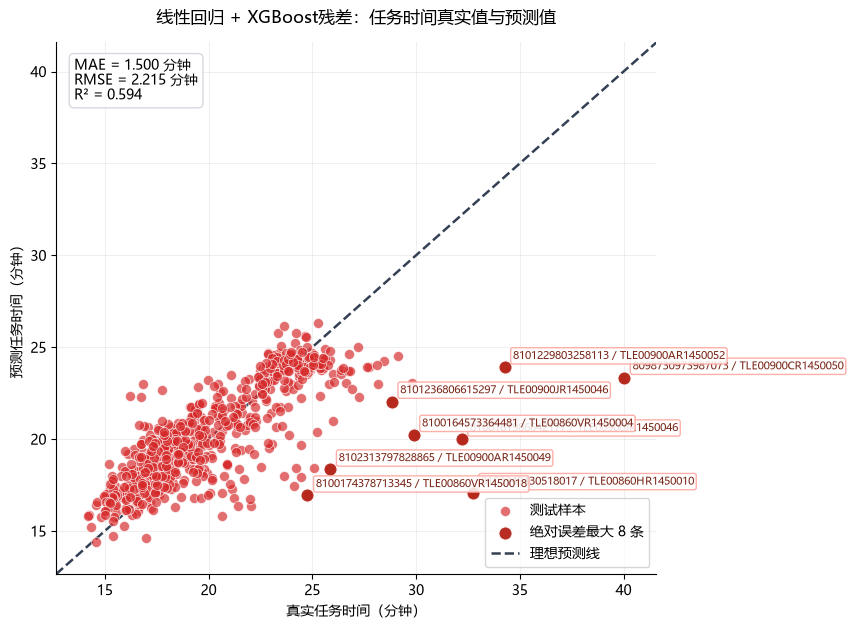

图中高亮任务：


C:\Users\14993\AppData\Local\Temp\ipykernel_12060\147247872.py:172: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(4)


,task_id,sn,actual_start_time,task_duration_min,prediction_min,signed_error_min,absolute_error_min
2610,8098730973987073,TLE00900CR1450050,2026-07-04 13:18:04.199,40.0333,23.3378,-16.6956,16.6956
3169,8103349430518017,TLE00860HR1450010,2026-07-07 19:36:10.160,32.7314,17.0636,-15.6678,15.6678
2791,8100161986642177,TLE00900JR1450046,2026-07-05 13:33:46.146,32.2000,19.9815,-12.2185,12.2185
2908,8101229803258113,TLE00900AR1450052,2026-07-06 07:39:59.114,34.2669,23.9048,-10.3621,10.3621
2792,8100164573364481,TLE00860VR1450004,2026-07-05 13:36:23.137,29.8833,20.2308,-9.6525,9.6525
2793,8100174378713345,TLE00860VR1450018,2026-07-05 13:46:22.155,24.7668,16.9332,-7.8335,7.8335
3040,8102313797828865,TLE00900AR1450049,2026-07-07 02:02:41.024,25.8668,18.3457,-7.5212,7.5212
2910,8101236806615297,TLE00900JR1450046,2026-07-06 07:47:07.136,28.8334,22.0383,-6.7951,6.7951


In [13]:
RESIDUAL_MODEL_NAME = "线性回归 + XGBoost残差"
RESIDUAL_PLOT_WORST_N = 8

residual_plot_result = model_results[RESIDUAL_MODEL_NAME]
residual_time_true = np.asarray(
    y_time_test,
    dtype=float,
)
residual_time_pred = np.asarray(
    residual_plot_result["time_pred"],
    dtype=float,
)
residual_time_error = (
    residual_time_pred - residual_time_true
)
residual_time_abs_error = np.abs(
    residual_time_error
)

worst_plot_positions = np.argsort(
    residual_time_abs_error
)[-RESIDUAL_PLOT_WORST_N:][::-1]

min_value = float(min(
    residual_time_true.min(),
    residual_time_pred.min(),
))
max_value = float(max(
    residual_time_true.max(),
    residual_time_pred.max(),
))
padding = max(
    (max_value - min_value) * 0.06,
    1e-9,
)
lower = min_value - padding
upper = max_value + padding

fig, ax = plt.subplots(figsize=(8.6, 6.4))

ax.scatter(
    residual_time_true,
    residual_time_pred,
    s=52,
    alpha=0.67,
    color=MODEL_COLORS[RESIDUAL_MODEL_NAME],
    edgecolors="white",
    linewidths=0.6,
    label="测试样本",
    zorder=3,
)

ax.scatter(
    residual_time_true[worst_plot_positions],
    residual_time_pred[worst_plot_positions],
    s=92,
    alpha=0.95,
    color="#B42318",
    edgecolors="white",
    linewidths=0.9,
    label=f"绝对误差最大 {RESIDUAL_PLOT_WORST_N} 条",
    zorder=4,
)

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.8,
    color="#344054",
    label="理想预测线",
    zorder=2,
)

for position in worst_plot_positions:
    task_id = test_df.iloc[position].get(
        "task_id",
        "",
    )
    sn = test_df.iloc[position].get(
        "sn",
        "",
    )
    annotation = f"{task_id} / {sn}"
    ax.annotate(
        annotation,
        (
            residual_time_true[position],
            residual_time_pred[position],
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="#7A271A",
        bbox={
            "boxstyle": "round,pad=0.20",
            "facecolor": "white",
            "edgecolor": "#FDA29B",
            "alpha": 0.86,
        },
        zorder=5,
    )

metrics = residual_plot_result["time_metrics"]
metric_text = (
    f"MAE = {metrics['MAE']:.3f} 分钟\n"
    f"RMSE = {metrics['RMSE']:.3f} 分钟\n"
    f"R² = {metrics['R2']:.3f}"
)
ax.text(
    0.03,
    0.97,
    metric_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#D0D5DD",
        "alpha": 0.90,
    },
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("真实任务时间（分钟）")
ax.set_ylabel("预测任务时间（分钟）")
ax.set_title(
    "线性回归 + XGBoost残差：任务时间真实值与预测值",
    pad=14,
)
ax.legend(loc="best")
ax.grid(alpha=0.20)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print("图中高亮任务：")
highlight_table = test_df.iloc[
    worst_plot_positions
][
    [
        column
        for column in [
            "task_id",
            "sn",
            "actual_start_time",
            TIME_TARGET,
        ]
        if column in test_df.columns
    ]
].copy()

highlight_table["prediction_min"] = (
    residual_time_pred[worst_plot_positions]
)
highlight_table["signed_error_min"] = (
    residual_time_error[worst_plot_positions]
)
highlight_table["absolute_error_min"] = (
    residual_time_abs_error[worst_plot_positions]
)

display(
    highlight_table
    .sort_values(
        "absolute_error_min",
        ascending=False,
    )
    .round(4)
)


## 12. LightGBM

LightGBM 特征重要性在后面同时输出：

- GAIN 总贡献；
- GAIN 百分比；
- 测试集置换重要性。

In [14]:
lgbm_pipeline = make_tree_pipeline(
    LGBMRegressor(
        objective="regression",
        colsample_bytree=0.90,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
        importance_type="gain",
    )
)

if FAST_MODE:
    lgbm_param_grid = {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.03, 0.08],
        "model__num_leaves": [15, 31],
        "model__min_child_samples": [10, 20],
    }
else:
    lgbm_param_grid = {
        "model__n_estimators": [150, 300, 500],
        "model__learning_rate": [0.02, 0.05, 0.10],
        "model__num_leaves": [7, 15, 31, 63],
        "model__min_child_samples": [10, 20, 40],
        "model__subsample": [0.80, 1.00],
    }

lgbm_result = run_two_target_grid_search(
    "LightGBM",
    lgbm_pipeline,
    lgbm_param_grid,
)


LightGBM 参数组合数：16
每个目标拟合约 64 次。
Fitting 4 folds for each of 16 candidates, totalling 64 fits
Fitting 4 folds for each of 16 candidates, totalling 64 fits

任务时间最优参数：


c:\Users\14993\PycharmProjects\BoLei-DataMining\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\14993\PycharmProjects\BoLei-DataMining\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,parameter,best_value
0,model__learning_rate,0.03
1,model__min_child_samples,20.00
2,model__n_estimators,200.00
3,model__num_leaves,31.00


任务时间训练集最优 CV RMSE：2.0968 分钟

任务能耗最优参数：


,parameter,best_value
0,model__learning_rate,0.03
1,model__min_child_samples,20.00
2,model__n_estimators,200.00
3,model__num_leaves,15.00


任务能耗训练集最优 CV RMSE：1.0458 SOC 百分点

测试集指标：


,MAE,RMSE,R2
任务时间,1.4521,2.1512,0.6174
任务能耗,0.6561,0.8493,0.9204


## 13. HGBR

HGBR 是 scikit-learn 的直方图梯度提升回归器。它没有标准 `feature_importances_`，因此后面使用置换重要性解释。

In [15]:
hgbr_pipeline = make_tree_pipeline(
    HistGradientBoostingRegressor(
        loss="squared_error",
        min_samples_leaf=20,
        early_stopping=False,
        random_state=RANDOM_STATE,
    )
)

if FAST_MODE:
    hgbr_param_grid = {
        "model__max_iter": [200, 400],
        "model__learning_rate": [0.03, 0.08],
        "model__max_leaf_nodes": [15, 31],
        "model__l2_regularization": [0.0, 1.0],
    }
else:
    hgbr_param_grid = {
        "model__max_iter": [150, 300, 500],
        "model__learning_rate": [0.02, 0.05, 0.10],
        "model__max_leaf_nodes": [7, 15, 31, 63],
        "model__min_samples_leaf": [10, 20, 40],
        "model__l2_regularization": [0.0, 0.5, 1.0, 3.0],
    }

hgbr_result = run_two_target_grid_search(
    "HGBR",
    hgbr_pipeline,
    hgbr_param_grid,
)


HGBR 参数组合数：16
每个目标拟合约 64 次。
Fitting 4 folds for each of 16 candidates, totalling 64 fits
Fitting 4 folds for each of 16 candidates, totalling 64 fits

任务时间最优参数：


,parameter,best_value
0,model__l2_regularization,0.00
1,model__learning_rate,0.03
2,model__max_iter,200.00
3,model__max_leaf_nodes,15.00


任务时间训练集最优 CV RMSE：2.1329 分钟

任务能耗最优参数：


,parameter,best_value
0,model__l2_regularization,1.00
1,model__learning_rate,0.03
2,model__max_iter,200.00
3,model__max_leaf_nodes,15.00


任务能耗训练集最优 CV RMSE：1.0629 SOC 百分点

测试集指标：


,MAE,RMSE,R2
任务时间,1.4235,2.1496,0.6180
任务能耗,0.6346,0.8268,0.9246


## 14. 随机森林

随机森林用于提供与提升树不同的袋装树模型对照。

In [16]:
rf_pipeline = make_tree_pipeline(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
)

if FAST_MODE:
    rf_param_grid = {
        "model__n_estimators": [300],
        "model__max_depth": [None, 12, 20],
        "model__min_samples_leaf": [1, 3],
        "model__max_features": ["sqrt", 0.80],
    }
else:
    rf_param_grid = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 8, 12, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.70, 1.00],
    }

rf_result = run_two_target_grid_search(
    "随机森林",
    rf_pipeline,
    rf_param_grid,
)


随机森林 参数组合数：12
每个目标拟合约 48 次。
Fitting 4 folds for each of 12 candidates, totalling 48 fits
Fitting 4 folds for each of 12 candidates, totalling 48 fits

任务时间最优参数：


,parameter,best_value
0,model__max_depth,12.0
1,model__max_features,0.8
2,model__min_samples_leaf,3.0
3,model__n_estimators,300.0


任务时间训练集最优 CV RMSE：2.1041 分钟

任务能耗最优参数：


,parameter,best_value
0,model__max_depth,20.0
1,model__max_features,0.8
2,model__min_samples_leaf,1.0
3,model__n_estimators,300.0


任务能耗训练集最优 CV RMSE：1.0274 SOC 百分点

测试集指标：


,MAE,RMSE,R2
任务时间,1.5241,2.1847,0.6054
任务能耗,0.6361,0.8328,0.9235


## 15. 绘制每个模型的测试集结果

按照参考版的展示方式，对以下全部模型逐一输出：

- 任务时间测试集指标、真实值—预测值图和残差图；
- 任务能耗测试集指标、真实值—预测值图和残差图。

模型包括规划距离比例 Baseline、线性回归、XGBoost、LightGBM、HGBR 和随机森林。

规划距离比例 Baseline


,MAE,RMSE,R2
任务时间,1.6440,2.3849,0.5297
任务能耗,1.4958,1.7994,0.6427


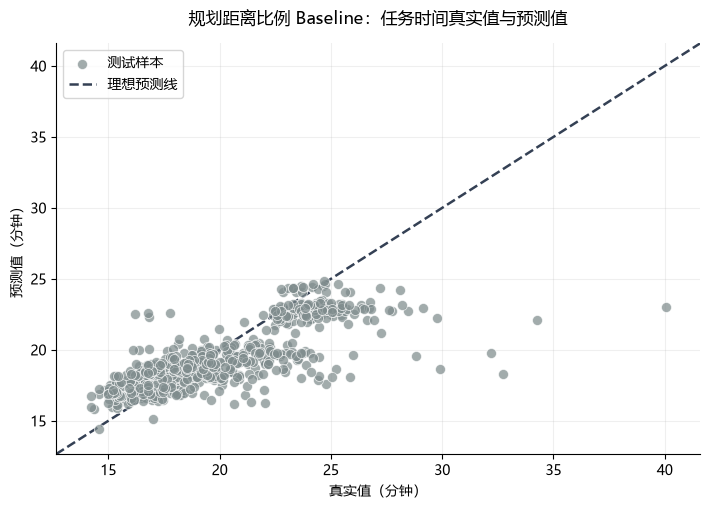

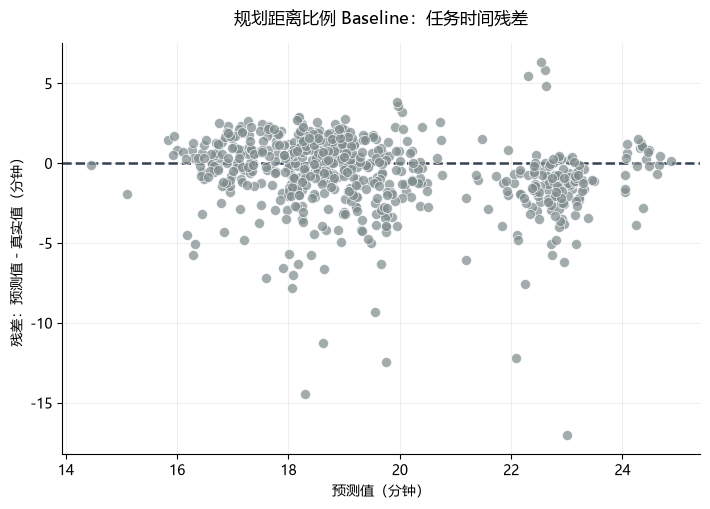

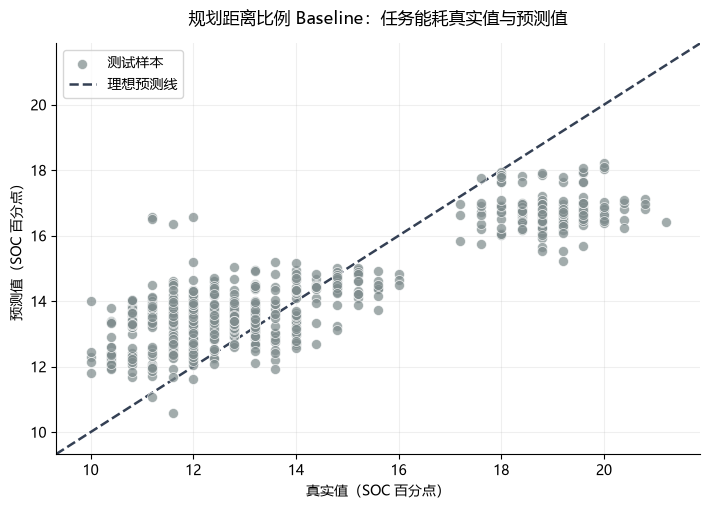

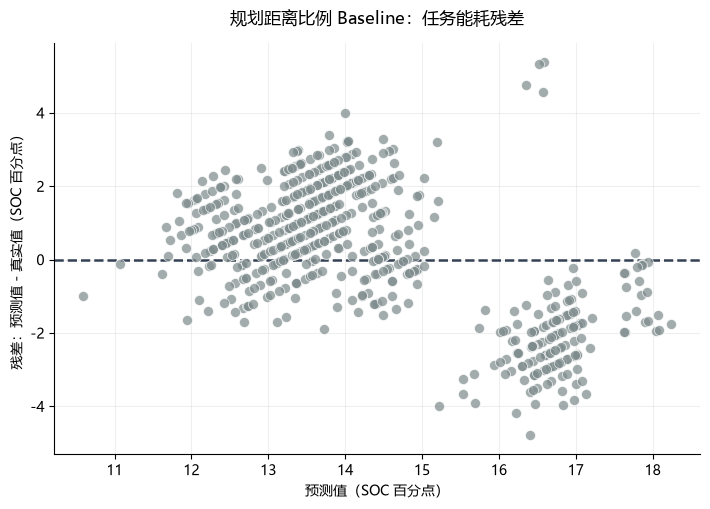

线性回归


,MAE,RMSE,R2
任务时间,1.4116,2.2197,0.5926
任务能耗,0.6263,0.8342,0.9232


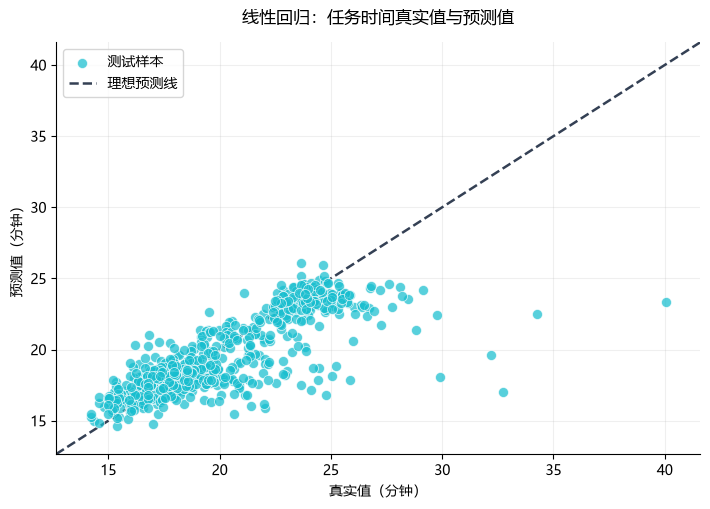

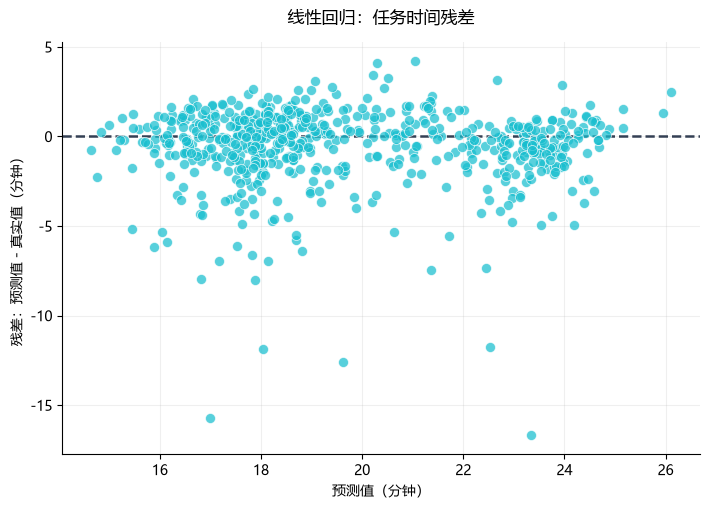

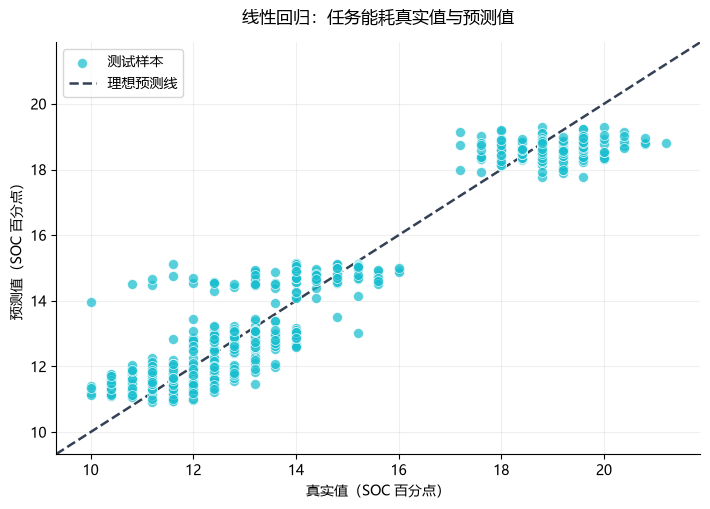

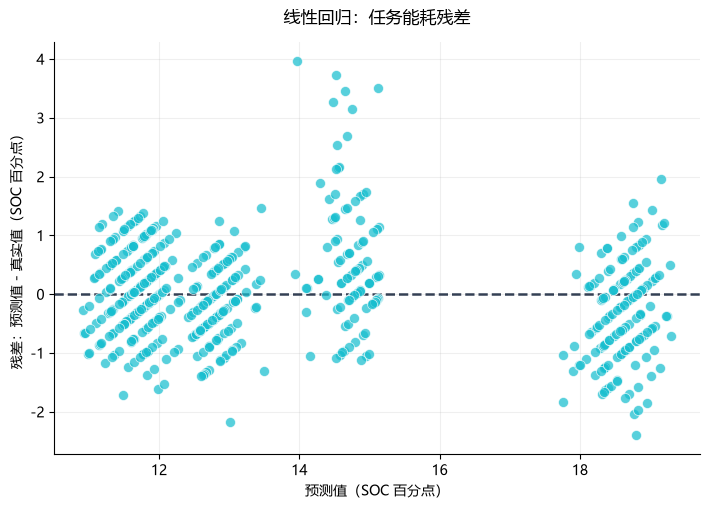

XGBoost


,MAE,RMSE,R2
任务时间,1.4230,2.1449,0.6196
任务能耗,0.6518,0.8414,0.9219


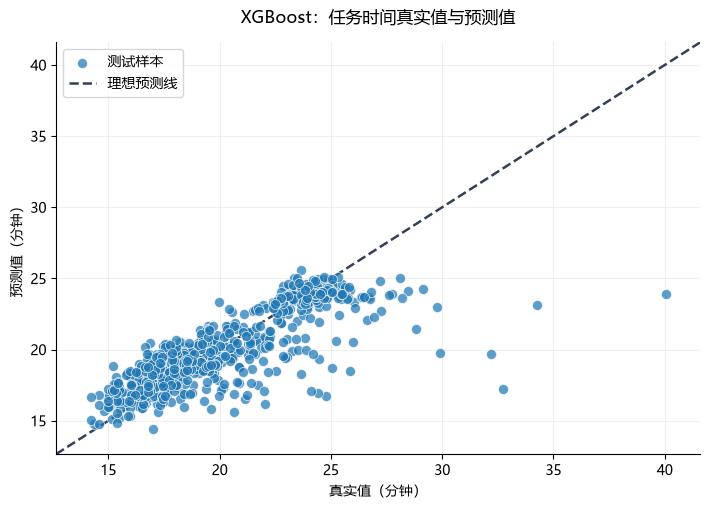

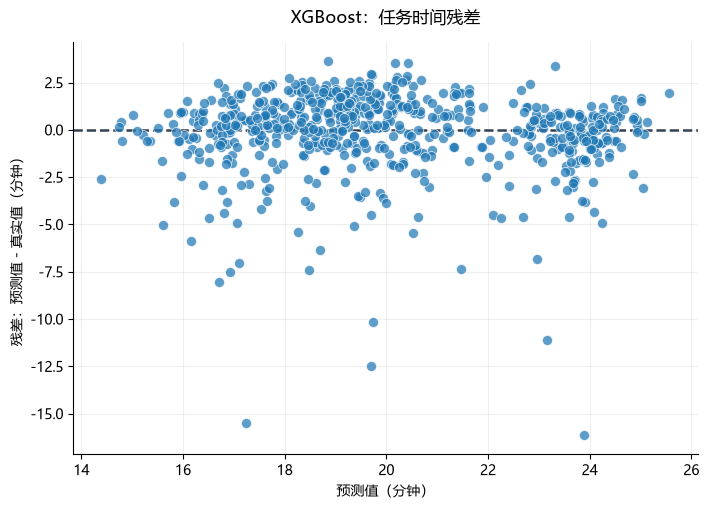

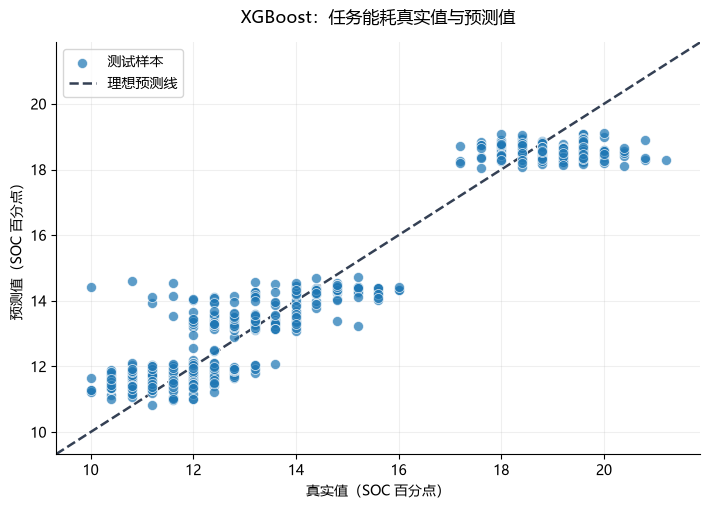

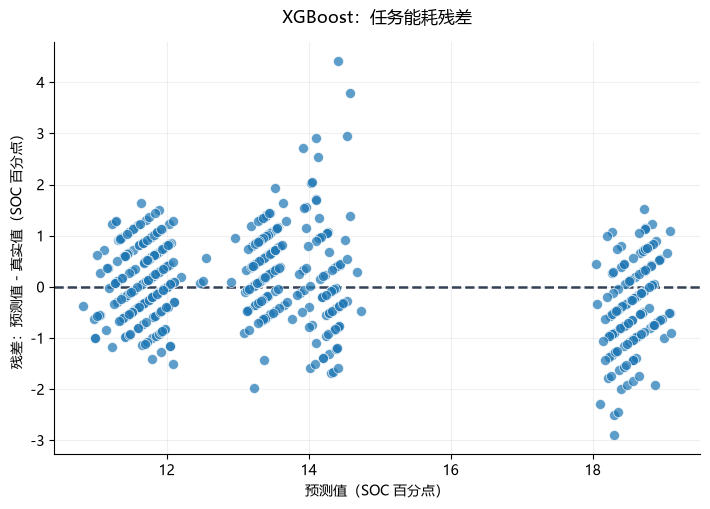

线性回归 + XGBoost残差


,MAE,RMSE,R2
任务时间,1.5001,2.2149,0.5944
任务能耗,0.6114,0.8014,0.9291


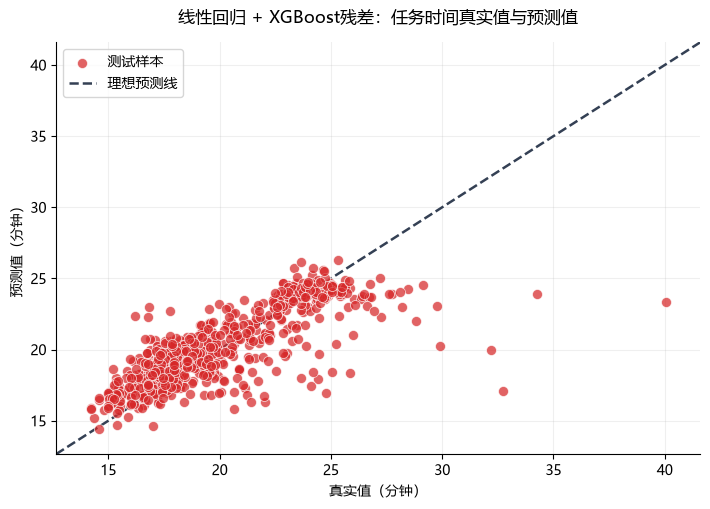

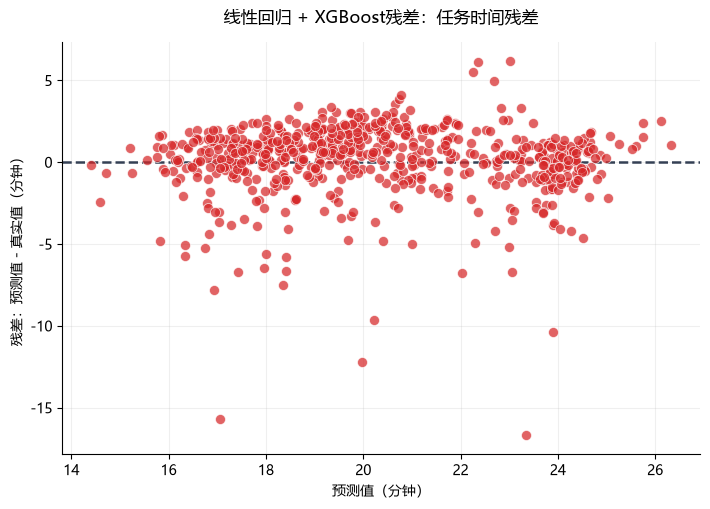

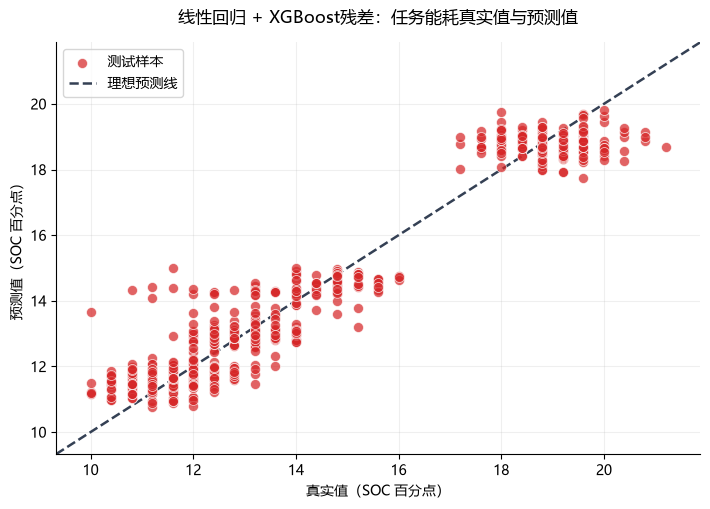

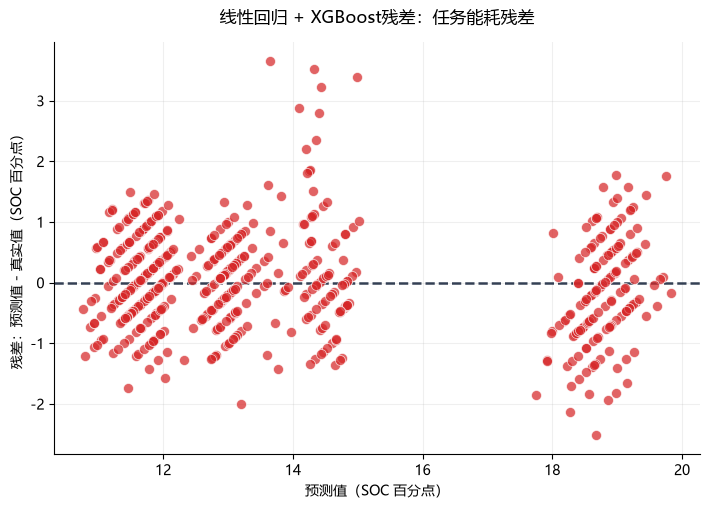

LightGBM


,MAE,RMSE,R2
任务时间,1.4521,2.1512,0.6174
任务能耗,0.6561,0.8493,0.9204


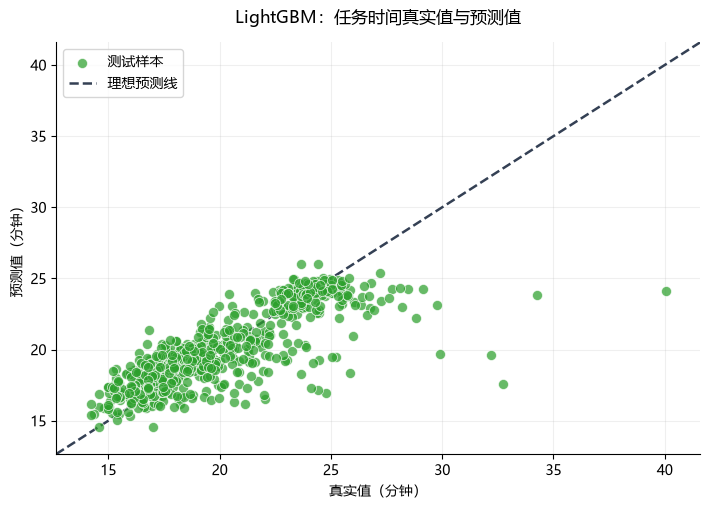

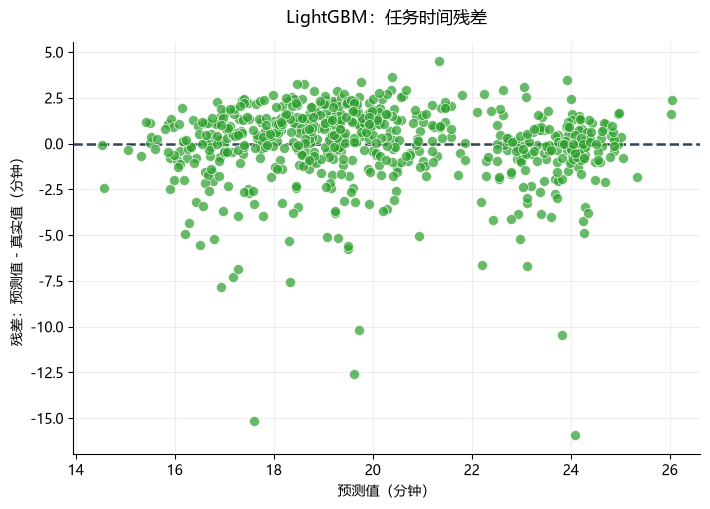

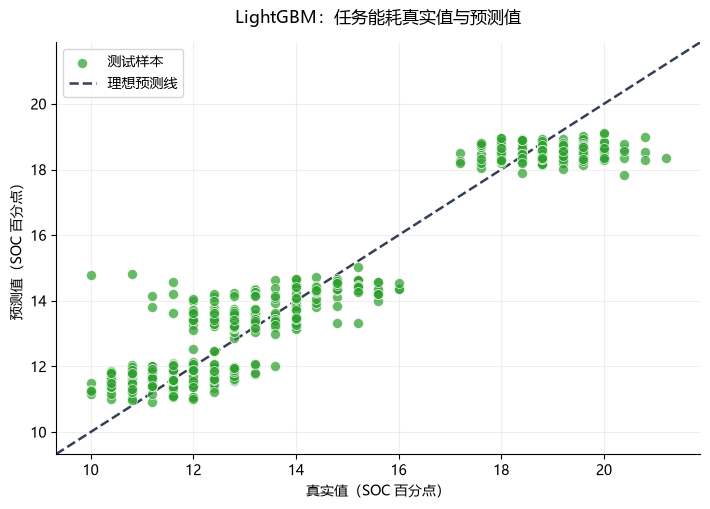

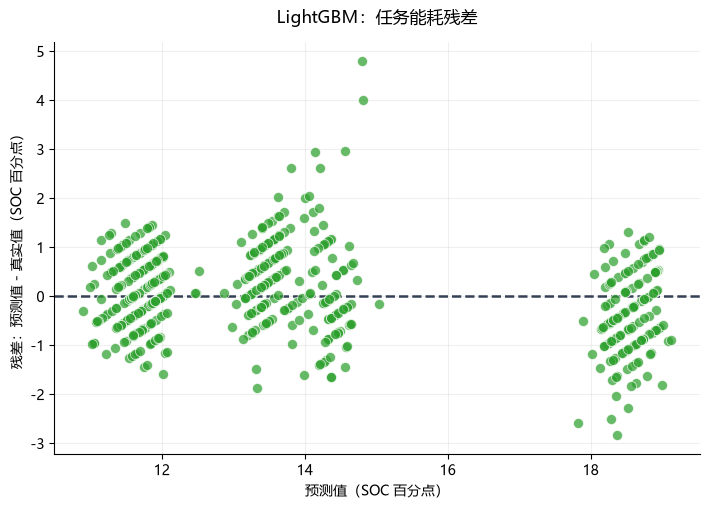

HGBR


,MAE,RMSE,R2
任务时间,1.4235,2.1496,0.6180
任务能耗,0.6346,0.8268,0.9246


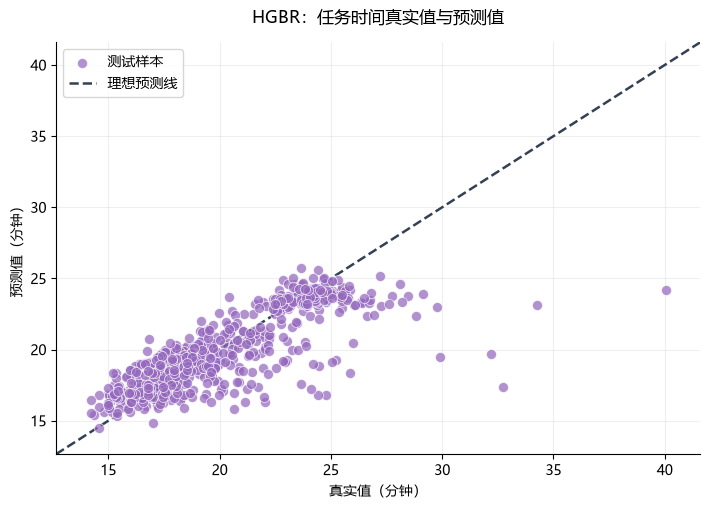

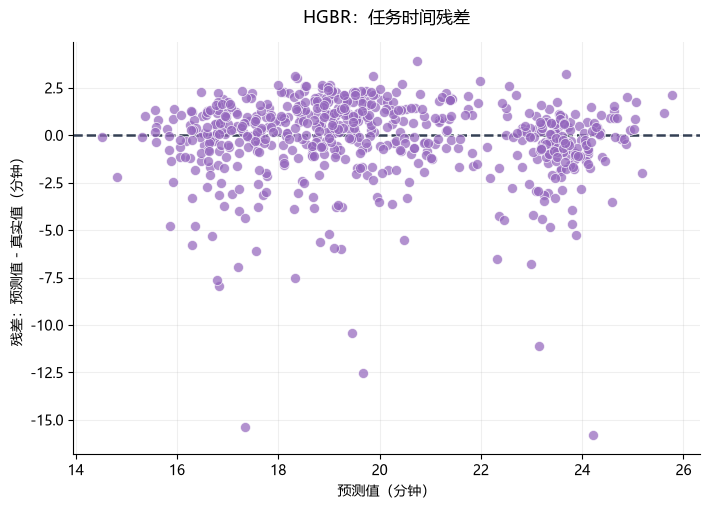

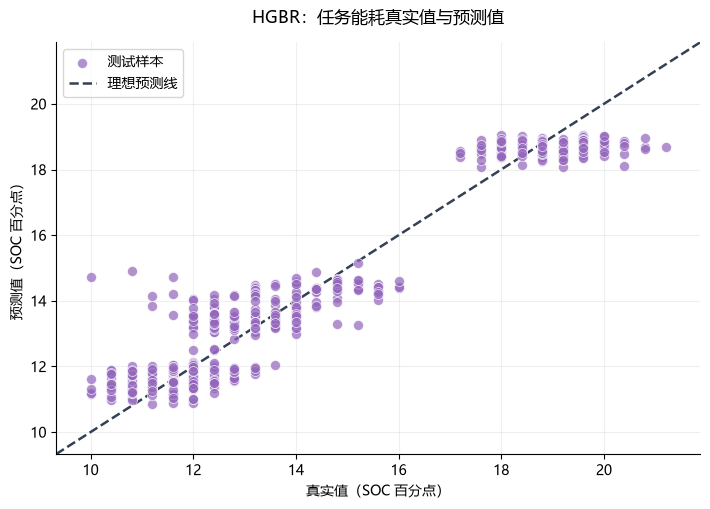

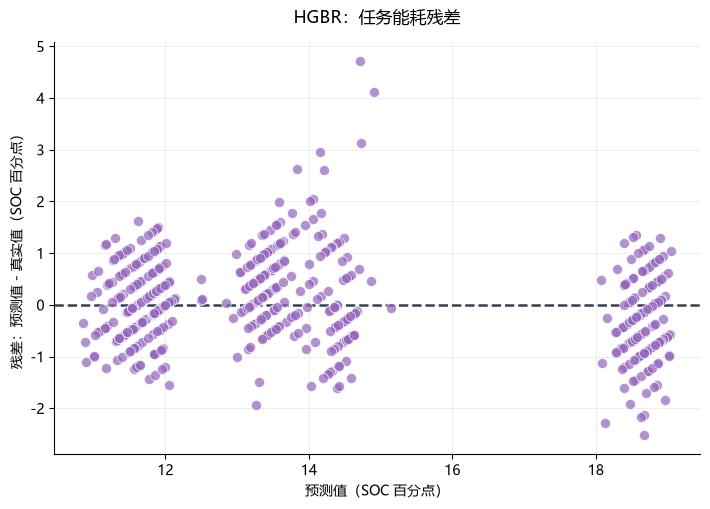

随机森林


,MAE,RMSE,R2
任务时间,1.5241,2.1847,0.6054
任务能耗,0.6361,0.8328,0.9235


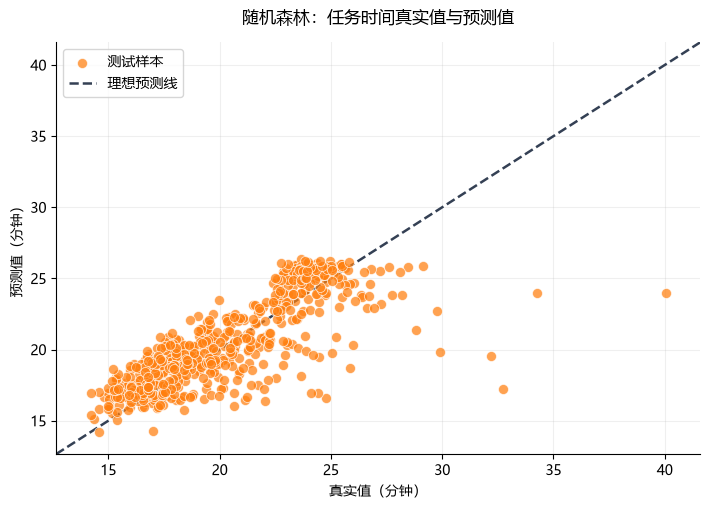

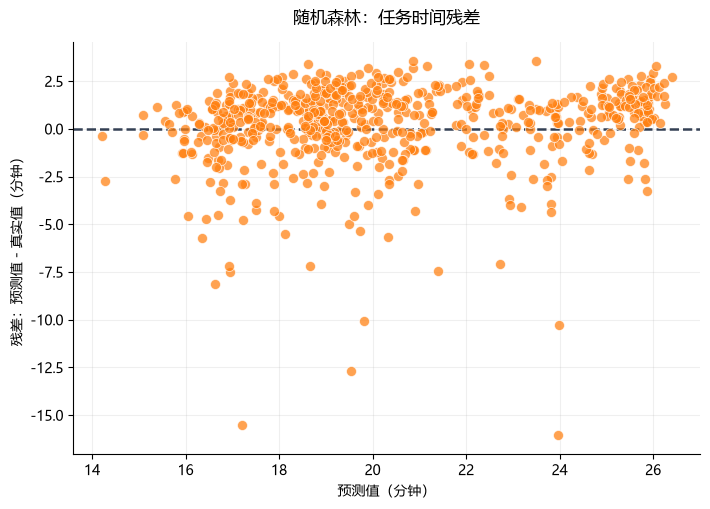

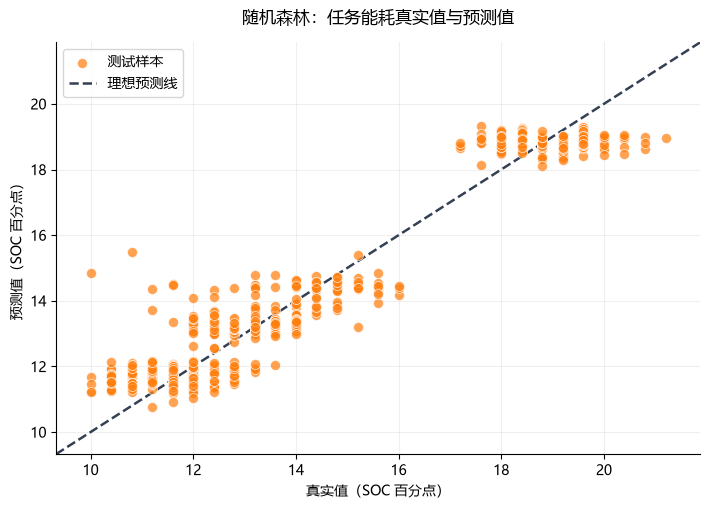

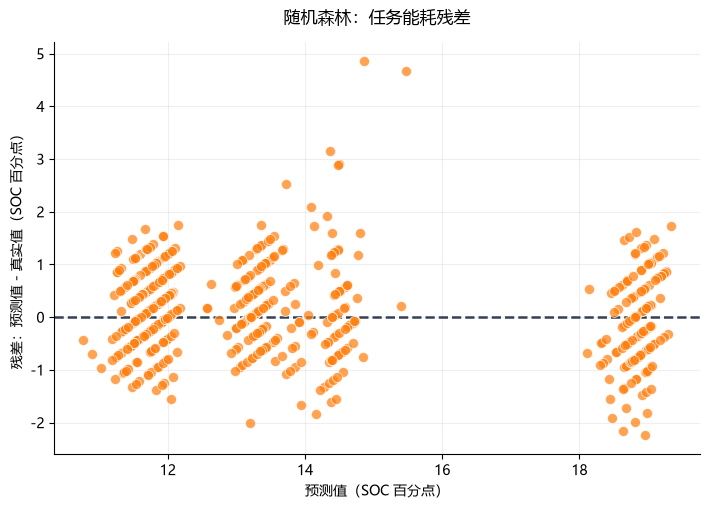

In [17]:
for model_name, result in model_results.items():
    plot_single_model_results(
        model_name=model_name,
        result=result,
        y_time_true=y_time_test,
        y_energy_true=y_energy_test,
    )


## 16. 测试集统一比较

所有模型使用完全相同的时间测试集。

In [18]:
time_comparison = pd.DataFrame([
    {
        "model": model_name,
        **result["time_metrics"],
    }
    for model_name, result in model_results.items()
]).set_index("model").sort_values("RMSE")

energy_comparison = pd.DataFrame([
    {
        "model": model_name,
        **result["energy_metrics"],
    }
    for model_name, result in model_results.items()
]).set_index("model").sort_values("RMSE")

print("任务时间测试集指标（分钟）：")
display(time_comparison.round(4))

print("任务能耗测试集指标（SOC 百分点）：")
display(energy_comparison.round(4))


任务时间测试集指标（分钟）：


,MAE,RMSE,R2
model,,,
XGBoost,1.4230,2.1449,0.6196
HGBR,1.4235,2.1496,0.6180
LightGBM,1.4521,2.1512,0.6174
随机森林,1.5241,2.1847,0.6054
线性回归 + XGBoost残差,1.5001,2.2149,0.5944
线性回归,1.4116,2.2197,0.5926
规划距离比例 Baseline,1.6440,2.3849,0.5297


任务能耗测试集指标（SOC 百分点）：


,MAE,RMSE,R2
model,,,
线性回归 + XGBoost残差,0.6114,0.8014,0.9291
HGBR,0.6346,0.8268,0.9246
随机森林,0.6361,0.8328,0.9235
线性回归,0.6263,0.8342,0.9232
XGBoost,0.6518,0.8414,0.9219
LightGBM,0.6561,0.8493,0.9204
规划距离比例 Baseline,1.4958,1.7994,0.6427


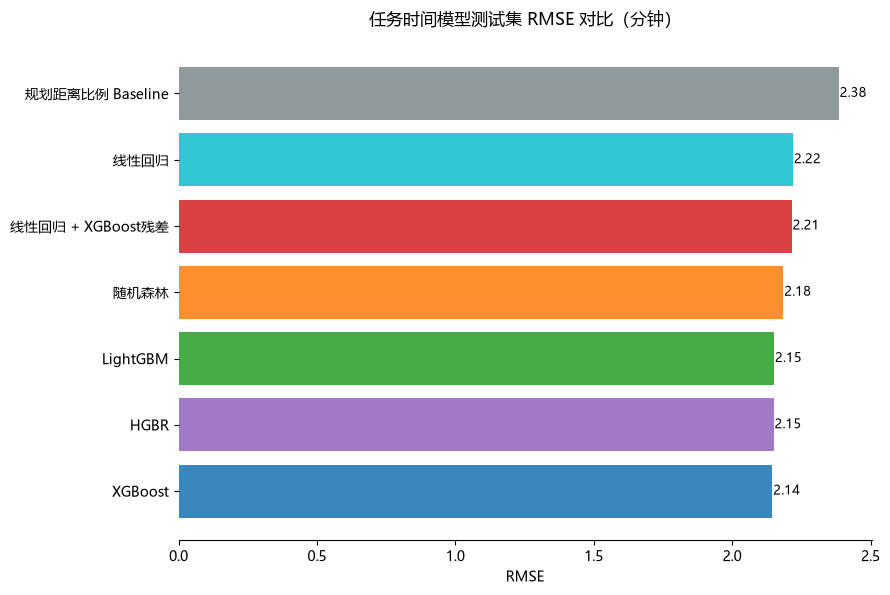

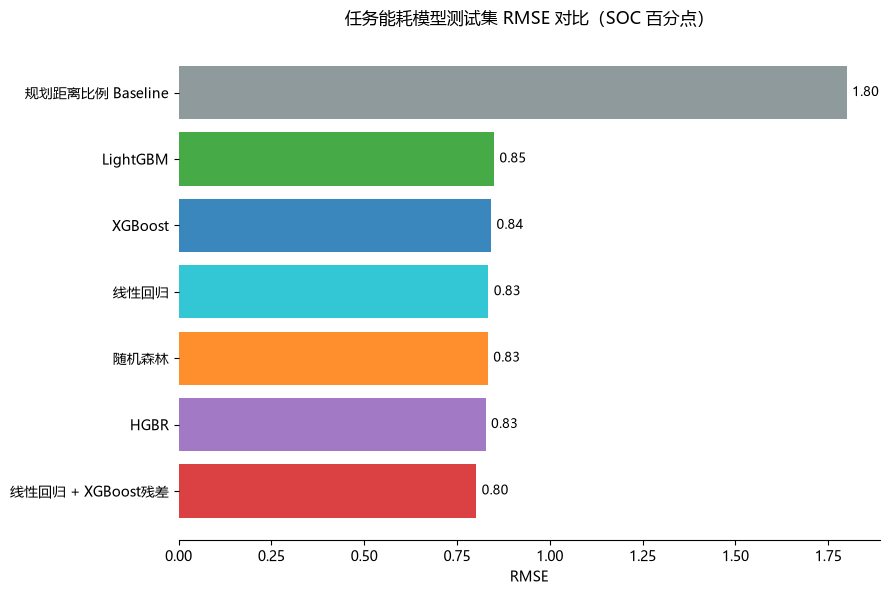

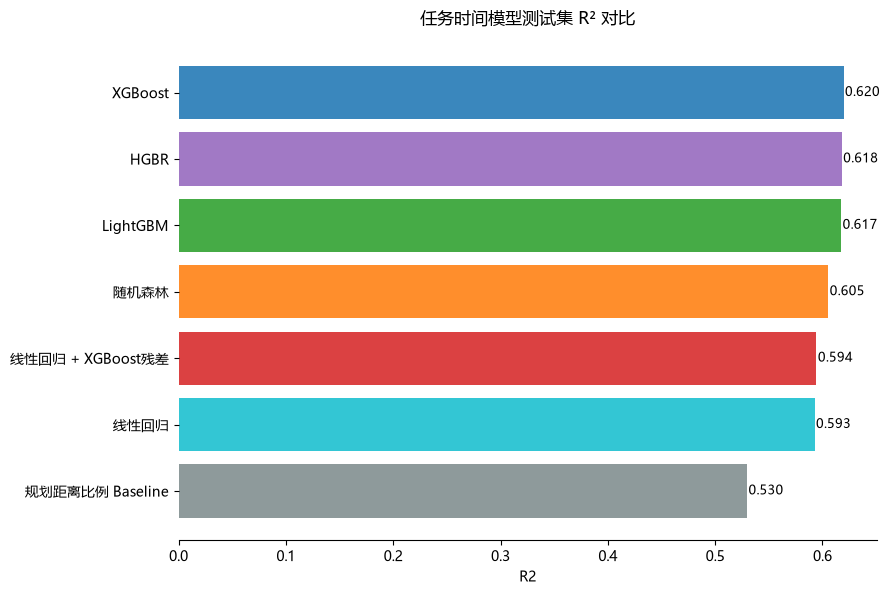

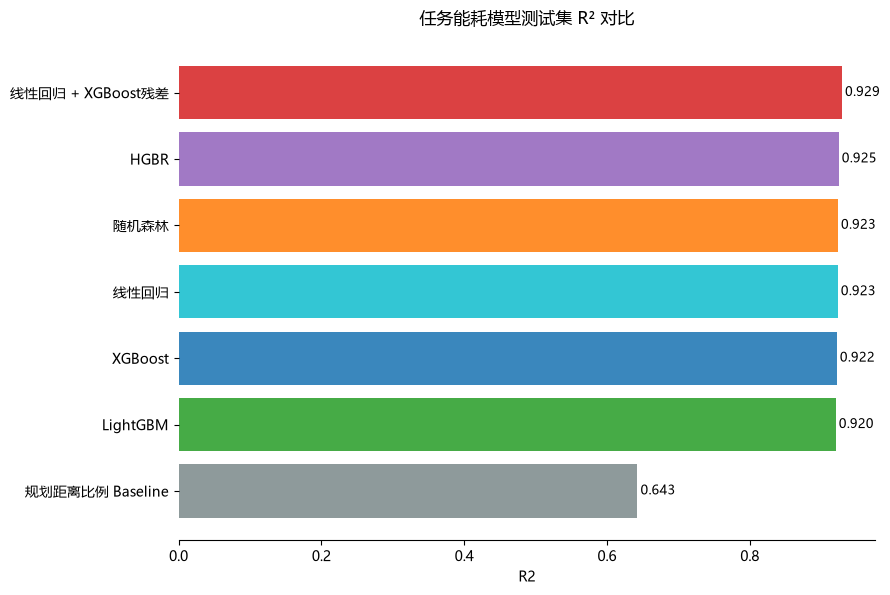

In [19]:
def plot_model_metric(comparison_df, metric, title):
    plot_df = comparison_df.sort_values(metric, ascending=True).copy()
    labels = list(plot_df.index)
    colors = [
        MODEL_COLORS.get(label, "#7F8C8D")
        for label in labels
    ]

    fig_height = max(5.2, 0.65 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(9.0, fig_height))
    bars = ax.barh(
        labels,
        plot_df[metric],
        color=colors,
        alpha=0.88,
    )

    values = plot_df[metric].to_numpy(dtype=float)
    value_span = max(
        float(values.max() - values.min()),
        float(np.max(np.abs(values))) * 0.1,
        1e-9,
    )
    decimal_places = 3 if metric == "R2" else 2

    for bar, value in zip(bars, values):
        ax.text(
            value + value_span * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.{decimal_places}f}",
            va="center",
            fontsize=9,
        )

    ax.set_xlabel(metric)
    ax.set_ylabel("")
    ax.set_title(title, pad=14)
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    fig.tight_layout()
    plt.show()


plot_model_metric(
    time_comparison,
    "RMSE",
    "任务时间模型测试集 RMSE 对比（分钟）",
)

plot_model_metric(
    energy_comparison,
    "RMSE",
    "任务能耗模型测试集 RMSE 对比（SOC 百分点）",
)

plot_model_metric(
    time_comparison,
    "R2",
    "任务时间模型测试集 R² 对比",
)

plot_model_metric(
    energy_comparison,
    "R2",
    "任务能耗模型测试集 R² 对比",
)


## 17. 最优模型摘要

分别选择任务时间和任务能耗测试集 RMSE 最低的模型。

In [20]:
best_time_model_name = time_comparison.index[0]
best_energy_model_name = energy_comparison.index[0]

print("任务时间最佳模型：", best_time_model_name)
display(
    time_comparison.loc[[best_time_model_name]].round(4)
)

print("任务能耗最佳模型：", best_energy_model_name)
display(
    energy_comparison.loc[[best_energy_model_name]].round(4)
)

print(
    "每个模型的真实值—预测值图和残差图已经在第 14 节完整绘制；"
    "此处只汇总测试集 RMSE 最低的模型。"
)


任务时间最佳模型： XGBoost


,MAE,RMSE,R2
model,,,
XGBoost,1.423,2.1449,0.6196


任务能耗最佳模型： 线性回归 + XGBoost残差


,MAE,RMSE,R2
model,,,
线性回归 + XGBoost残差,0.6114,0.8014,0.9291


每个模型的真实值—预测值图和残差图已经在第 14 节完整绘制；此处只汇总测试集 RMSE 最低的模型。


## 18. 测试集置换特征重要性

置换重要性衡量：

> 随机打乱某个原始特征后，测试集 RMSE 恶化多少。

它适用于所有流水线模型，包括 HGBR，并且仍按原始 8 个特征显示。

In [21]:
def get_permutation_importance(
    fitted_pipeline,
    X,
    y,
    feature_names,
    n_repeats=10,
):
    result = permutation_importance(
        fitted_pipeline,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=GRID_SEARCH_N_JOBS,
    )

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values(
        "importance_mean",
        ascending=False,
    )

    return importance_df


def plot_importance(importance_df, title):
    plot_df = importance_df.sort_values("importance_mean")

    plt.figure(figsize=(9, 6))
    plt.barh(
        plot_df["feature"],
        plot_df["importance_mean"],
        xerr=plot_df["importance_std"],
    )
    plt.xlabel("打乱后 RMSE 增量")
    plt.ylabel("特征")
    plt.title(title)
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


permutation_tables = {}

for model_name in ["XGBoost", "LightGBM", "HGBR", "随机森林"]:
    result = model_results[model_name]

    time_importance = get_permutation_importance(
        result["time_model"],
        X_test,
        y_time_test,
        FEATURE_COLS,
    )
    energy_importance = get_permutation_importance(
        result["energy_model"],
        X_test,
        y_energy_test,
        FEATURE_COLS,
    )

    permutation_tables[(model_name, "time")] = time_importance
    permutation_tables[(model_name, "energy")] = energy_importance

    print(f"\n{model_name}：任务时间置换重要性")
    display(time_importance.round(6))

    print(f"{model_name}：任务能耗置换重要性")
    display(energy_importance.round(6))



XGBoost：任务时间置换重要性


,feature,importance_mean,importance_std
8,similar_task_actual_distance_km,0.361404,0.026593
11,similar_top3_duration_mean_sec,0.337064,0.019708
9,similar_task_duration_min,0.214994,0.013585
1,planned_total_distance_m,0.154169,0.012459
2,endpoint_altitude_change_m,0.145419,0.019914
0,straight_line_distance_m,0.011457,0.010391
13,fleet_prev60m_speed_mean,0.004031,0.008047
12,similar_top3_od_distance_mean_m,0.002460,0.001839
7,vehicle_prev1_duration_sec,0.001155,0.003135
14,fleet_prev60m_speed_min,-0.000087,0.000091


XGBoost：任务能耗置换重要性


,feature,importance_mean,importance_std
2,endpoint_altitude_change_m,1.750762,0.063838
5,planned_cumulative_ascent_m,0.521683,0.030583
10,similar_task_energy_soc_delta_pct,0.116196,0.008315
1,planned_total_distance_m,0.078707,0.006398
9,similar_task_duration_min,0.062641,0.006039
8,similar_task_actual_distance_km,0.052646,0.004899
3,planned_slope_mean,0.022811,0.004385
11,similar_top3_duration_mean_sec,0.015208,0.002104
14,fleet_prev60m_speed_min,0.001824,0.001659
7,vehicle_prev1_duration_sec,0.000885,0.000553


c:\Users\14993\PycharmProjects\BoLei-DataMining\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\14993\PycharmProjects\BoLei-DataMining\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

,feature,importance_mean,importance_std
2,endpoint_altitude_change_m,2.121971,0.074717
5,planned_cumulative_ascent_m,0.234868,0.018705
10,similar_task_energy_soc_delta_pct,0.132626,0.010712
1,planned_total_distance_m,0.122013,0.008570
9,similar_task_duration_min,0.116100,0.010210
8,similar_task_actual_distance_km,0.051608,0.004980
11,similar_top3_duration_mean_sec,0.006167,0.002095
0,straight_line_distance_m,0.005620,0.001918
3,planned_slope_mean,0.004784,0.001433
7,vehicle_prev1_duration_sec,0.001783,0.001382



随机森林：任务时间置换重要性


,feature,importance_mean,importance_std
11,similar_top3_duration_mean_sec,0.458661,0.029278
9,similar_task_duration_min,0.328450,0.023287
8,similar_task_actual_distance_km,0.175927,0.018417
2,endpoint_altitude_change_m,0.100515,0.011362
3,planned_slope_mean,0.047002,0.004721
1,planned_total_distance_m,0.028899,0.009564
14,fleet_prev60m_speed_min,0.000944,0.001010
0,straight_line_distance_m,0.000814,0.005085
13,fleet_prev60m_speed_mean,0.000535,0.008695
12,similar_top3_od_distance_mean_m,-0.003552,0.001847


随机森林：任务能耗置换重要性


,feature,importance_mean,importance_std
2,endpoint_altitude_change_m,1.991123,0.072735
5,planned_cumulative_ascent_m,0.262286,0.017181
9,similar_task_duration_min,0.106160,0.010268
1,planned_total_distance_m,0.101969,0.011855
10,similar_task_energy_soc_delta_pct,0.051261,0.006063
8,similar_task_actual_distance_km,0.014697,0.001866
11,similar_top3_duration_mean_sec,0.006898,0.007807
0,straight_line_distance_m,0.005020,0.003361
3,planned_slope_mean,0.003866,0.002032
7,vehicle_prev1_duration_sec,0.003325,0.001080


## 19. LightGBM GAIN 特征重要性

GAIN 不是百分比，原始值可能是几百或几千。这里同时输出：

- `gain`：累计损失下降；
- `gain_pct`：归一化后的贡献百分比。

因为填补器开启了缺失指示变量，表中可能出现 `missingindicator_...` 特征。

In [22]:
def get_transformed_feature_names(fitted_pipeline, raw_feature_names):
    imputer = fitted_pipeline.named_steps["imputer"]
    return list(imputer.get_feature_names_out(raw_feature_names))


def get_lgbm_gain_table(fitted_pipeline, raw_feature_names):
    transformed_names = get_transformed_feature_names(
        fitted_pipeline,
        raw_feature_names,
    )
    model = fitted_pipeline.named_steps["model"]

    gain = model.booster_.feature_importance(
        importance_type="gain"
    )

    table = pd.DataFrame({
        "feature": transformed_names,
        "gain": gain,
    })
    gain_sum = float(table["gain"].sum())
    table["gain_pct"] = (
        table["gain"] / gain_sum * 100
        if gain_sum > 0
        else 0.0
    )

    return table.sort_values(
        "gain_pct",
        ascending=False,
    )


lgbm_time_gain = get_lgbm_gain_table(
    model_results["LightGBM"]["time_model"],
    FEATURE_COLS,
)
lgbm_energy_gain = get_lgbm_gain_table(
    model_results["LightGBM"]["energy_model"],
    FEATURE_COLS,
)

print("LightGBM 任务时间 GAIN 重要性：")
display(lgbm_time_gain.round(6))

print("LightGBM 任务能耗 GAIN 重要性：")
display(lgbm_energy_gain.round(6))


LightGBM 任务时间 GAIN 重要性：


,feature,gain,gain_pct
11,similar_top3_duration_mean_sec,192534.024063,48.572351
9,similar_task_duration_min,95783.320517,24.164150
8,similar_task_actual_distance_km,28766.991462,7.257317
1,planned_total_distance_m,17099.982779,4.313972
0,straight_line_distance_m,9023.964449,2.276560
13,fleet_prev60m_speed_mean,8199.956097,2.068679
2,endpoint_altitude_change_m,7380.953721,1.862062
12,similar_top3_od_distance_mean_m,6480.750357,1.634959
3,planned_slope_mean,6394.741428,1.613261
5,planned_cumulative_ascent_m,6145.254048,1.550320


LightGBM 任务能耗 GAIN 重要性：


,feature,gain,gain_pct
2,endpoint_altitude_change_m,186676.186568,77.519918
5,planned_cumulative_ascent_m,33314.890728,13.834478
9,similar_task_duration_min,4816.333838,2.000051
10,similar_task_energy_soc_delta_pct,4069.914676,1.690089
1,planned_total_distance_m,3396.086494,1.410273
0,straight_line_distance_m,2500.372444,1.038315
8,similar_task_actual_distance_km,1292.987750,0.536931
4,planned_slope_std,909.404334,0.377643
11,similar_top3_duration_mean_sec,888.100427,0.368796
3,planned_slope_mean,677.978750,0.281540


## 20. 查看测试集逐条预测

结果包含所有模型对每条未来测试任务的预测。

In [23]:
prediction_result = test_df[
    [
        "task_id",
        "sn",
        "actual_start_time",
        "actual_end_time",
        *FEATURE_COLS,
        TIME_TARGET,
        ENERGY_TARGET,
    ]
].copy()

for model_name, result in model_results.items():
    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("（", "_")
        .replace("）", "")
    )
    prediction_result[
        f"{safe_name}_time_pred_min"
    ] = result["time_pred"]
    prediction_result[
        f"{safe_name}_energy_pred_pct"
    ] = result["energy_pred"]

display(prediction_result.head(10))


,task_id,sn,actual_start_time,actual_end_time,straight_line_distance_m,planned_total_distance_m,endpoint_altitude_change_m,planned_slope_mean,planned_slope_std,planned_cumulative_ascent_m,planned_cumulative_descent_m,vehicle_prev1_duration_sec,similar_task_actual_distance_km,similar_task_duration_min,similar_task_energy_soc_delta_pct,similar_top3_duration_mean_sec,similar_top3_od_distance_mean_m,fleet_prev60m_speed_mean,fleet_prev60m_speed_min,task_duration_min,total_energy_soc_delta_pct,规划距离比例_Baseline_time_pred_min,规划距离比例_Baseline_energy_pred_pct,线性回归_time_pred_min,线性回归_energy_pred_pct,XGBoost_time_pred_min,XGBoost_energy_pred_pct,线性回归_+_XGBoost残差_time_pred_min,线性回归_+_XGBoost残差_energy_pred_pct,LightGBM_time_pred_min,LightGBM_energy_pred_pct,HGBR_time_pred_min,HGBR_energy_pred_pct,随机森林_time_pred_min,随机森林_energy_pred_pct
2554,8098325855617281,TLE00900AR1450049,2026-07-04 06:25:58.011,2026-07-04 06:53:09.007,2611.231686,4715.908390,185.5402,0.040294,0.033804,180.251,0.948,1089.994,4.625,25.550133,19.2,1444.658667,56.102506,3.292654,0.001,27.183267,18.0,24.371799,17.867058,24.150662,18.843240,24.844217,18.899057,25.025125,19.210357,25.346142,18.711528,25.182108,18.889561,25.509775,18.614519
2555,8098327176052993,TLE00900VR1450048,2026-07-04 06:27:18.053,2026-07-04 06:49:03.114,3044.922713,3964.687431,128.9359,0.034174,0.036227,133.273,4.517,1208.989,3.625,21.016333,15.2,1224.797000,46.968546,3.280668,0.001,21.751017,14.8,20.489492,15.020924,19.623923,13.494486,20.621815,13.372969,20.466553,13.607117,20.496397,13.316953,20.941489,13.300136,20.209151,13.719034
2556,8098336117981441,TLE00900CR1450050,2026-07-04 06:36:24.007,2026-07-04 06:58:22.241,2384.176093,3718.806052,147.3129,0.037750,0.033323,134.705,0.879,1449.786,4.125,19.783333,12.0,1218.333000,39.402205,3.339744,0.001,21.970567,14.4,19.218778,14.089359,20.725430,14.098854,20.726524,13.768950,21.082074,13.730835,21.025323,13.819593,20.907361,13.798737,20.856258,13.559340
2557,8098344060829953,TLE00860CR1450020,2026-07-04 06:44:29.044,2026-07-04 07:05:02.060,2351.645859,3768.411119,147.1248,0.037281,0.033632,134.878,0.841,1357.999,4.250,20.817400,13.6,1400.939000,49.267155,3.390052,0.001,20.550267,12.4,19.475137,14.277296,22.011082,14.546980,22.652782,14.109066,22.534291,14.242633,23.091435,14.119433,22.686310,14.064709,22.274731,13.685167
2558,8098350477672705,TLE00860VR1450004,2026-07-04 06:51:01.122,2026-07-04 07:09:08.121,3043.089161,3948.635455,128.9992,0.034171,0.036300,132.855,4.058,1533.008,3.500,21.751017,14.8,1222.670667,37.121454,3.094997,0.001,18.116650,13.2,20.406535,14.960108,19.697866,13.377696,19.868107,13.380557,20.124226,13.555307,19.107366,13.331959,19.722863,13.444331,19.705426,13.703833
2559,8098351104459009,TLE00860ER1450011,2026-07-04 06:51:39.041,2026-07-04 07:14:59.047,2639.019568,4705.741830,185.9136,0.040413,0.033947,180.000,0.824,1228.010,4.750,22.650050,18.8,1450.329333,52.364250,3.084748,0.001,23.333433,18.4,24.319259,17.828540,24.420469,18.762406,25.008749,18.927885,25.756350,19.198305,24.962008,18.902690,24.619287,18.954731,25.936924,19.268254
2560,8098354432672001,TLE00900AR1450052,2026-07-04 06:55:02.040,2026-07-04 07:14:19.037,3001.278985,4013.860527,128.7666,0.033725,0.036155,132.825,4.448,1357.913,3.875,19.433150,14.0,1228.422667,38.339152,3.129327,0.001,19.283283,13.6,20.743618,15.207225,20.226480,13.371702,20.118975,13.249687,20.944094,13.551307,20.567183,13.239386,20.705450,13.259196,20.108772,13.410597
2561,8098357441855745,TLE00900JR1450046,2026-07-04 06:58:06.132,2026-07-04 07:20:05.141,2376.939625,3719.013911,147.3342,0.037692,0.033208,134.547,0.520,1309.682,3.750,20.433033,13.2,1238.988667,31.994487,3.127888,0.001,21.983483,14.0,19.219852,14.090146,20.550485,14.262506,20.902853,13.881013,21.011853,14.111827,21.295301,13.886652,21.314687,13.851098,20.879081,13.535762
2562,8098372112351489,TLE00900AR1450049,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,2382.991285,3717.967159,147.4096,0.037769,0.033376,135.164,1.137,1630.996,3.750

## 21. 残差模型差任务与相似任务诊断

本节以“线性回归 + XGBoost残差”的任务时间预测为准：

1. 输出绝对误差最大的测试任务及其 `task_id`、`sn`；
2. 对每个差任务，在训练集中按全部模型特征寻找最相似的若干任务；
3. 比较任务之间的标准化特征距离和真实时间标签差异；
4. 筛选“特征很相近，但标签差异很大”的可疑任务对。

相似度仅使用 `FEATURE_COLS`，不会使用任务时间或能耗标签。

配置项：

```python
WORST_TASK_TOP_N = 10
SIMILAR_TASK_K = 5
FEATURE_CLOSE_THRESHOLD_Z = 0.60
LABEL_GAP_THRESHOLD_MIN = 3.0
```

`feature_rms_z_distance` 越小，表示两个任务的模型输入特征越相近。


In [24]:
# =========================
# 差任务与近邻诊断配置
# =========================
DIAGNOSTIC_MODEL_NAME = "线性回归 + XGBoost残差"
WORST_TASK_TOP_N = 10
SIMILAR_TASK_K = 5

# 标准化特征的均方根距离阈值。
# 越小表示越严格地要求特征相近。
FEATURE_CLOSE_THRESHOLD_Z = 0.60

# 真实时长相差达到该值时，视为标签差异较大。
LABEL_GAP_THRESHOLD_MIN = 3.0

diagnostic_result = model_results[
    DIAGNOSTIC_MODEL_NAME
]
diagnostic_prediction = np.asarray(
    diagnostic_result["time_pred"],
    dtype=float,
)
diagnostic_true = np.asarray(
    y_time_test,
    dtype=float,
)
diagnostic_signed_error = (
    diagnostic_prediction - diagnostic_true
)
diagnostic_abs_error = np.abs(
    diagnostic_signed_error
)

identity_columns = [
    column
    for column in [
        "task_id",
        "sn",
        "transport_device_id",
        "source_file",
        "source_task_index",
        "actual_start_time",
        "actual_end_time",
    ]
    if column in test_df.columns
]

worst_task_table = test_df[
    identity_columns
    + FEATURE_COLS
    + [TIME_TARGET]
].copy()

worst_task_table[
    "residual_model_prediction_min"
] = diagnostic_prediction
worst_task_table[
    "signed_error_min"
] = diagnostic_signed_error
worst_task_table[
    "absolute_error_min"
] = diagnostic_abs_error
worst_task_table[
    "error_direction"
] = np.where(
    diagnostic_signed_error >= 0,
    "预测偏长",
    "预测偏短",
)

worst_task_table = (
    worst_task_table
    .sort_values(
        "absolute_error_min",
        ascending=False,
    )
    .head(WORST_TASK_TOP_N)
    .reset_index(drop=True)
)
worst_task_table.insert(
    0,
    "worst_rank",
    np.arange(len(worst_task_table)) + 1,
)

print(
    f"{DIAGNOSTIC_MODEL_NAME} "
    f"绝对误差最大的前 {WORST_TASK_TOP_N} 条任务："
)

worst_display_columns = [
    column
    for column in [
        "worst_rank",
        "task_id",
        "sn",
        "source_file",
        "source_task_index",
        "actual_start_time",
        TIME_TARGET,
        "residual_model_prediction_min",
        "signed_error_min",
        "absolute_error_min",
        "error_direction",
        "planned_total_distance_m",
        "similar_task_duration_min",
        "similar_top3_duration_mean_sec",
        "similar_top3_od_distance_mean_m",
        "fleet_prev60m_speed_mean",
        "fleet_prev60m_speed_min",
    ]
    if column in worst_task_table.columns
]
display(
    worst_task_table[
        worst_display_columns
    ].round(4)
)


# ---------------------------------------------------------
# 使用训练集拟合缺失值填补和标准化器。
# 相似任务候选全部来自训练集，因此时间上早于测试任务。
# ---------------------------------------------------------
diagnostic_imputer = SimpleImputer(
    strategy="median",
)
diagnostic_scaler = StandardScaler()

train_feature_imputed = (
    diagnostic_imputer.fit_transform(
        train_df[FEATURE_COLS]
    )
)
train_feature_z = (
    diagnostic_scaler.fit_transform(
        train_feature_imputed
    )
)

worst_feature_imputed = (
    diagnostic_imputer.transform(
        worst_task_table[FEATURE_COLS]
    )
)
worst_feature_z = (
    diagnostic_scaler.transform(
        worst_feature_imputed
    )
)

feature_count = len(FEATURE_COLS)
similar_task_rows = []
feature_comparison_rows = []


def format_feature_value(value):
    if pd.isna(value):
        return "NA"
    try:
        return f"{float(value):.4g}"
    except (TypeError, ValueError):
        return str(value)


for target_position, target_row in (
    worst_task_table.iterrows()
):
    target_z = worst_feature_z[target_position]

    # RMS z距离比普通欧氏距离更不受特征数量影响。
    z_difference = (
        train_feature_z - target_z
    )
    feature_rms_z_distance = np.sqrt(
        np.mean(
            z_difference ** 2,
            axis=1,
        )
    )

    nearest_positions = np.argsort(
        feature_rms_z_distance
    )[:SIMILAR_TASK_K]

    target_label = float(
        target_row[TIME_TARGET]
    )

    for neighbor_rank, train_position in enumerate(
        nearest_positions,
        start=1,
    ):
        neighbor_row = train_df.iloc[
            train_position
        ]
        neighbor_label = float(
            neighbor_row[TIME_TARGET]
        )

        abs_z_diff = np.abs(
            z_difference[train_position]
        )
        top_difference_positions = np.argsort(
            abs_z_diff
        )[::-1][:5]

        top_feature_differences = []
        for feature_position in (
            top_difference_positions
        ):
            feature_name = FEATURE_COLS[
                feature_position
            ]
            target_value = target_row.get(
                feature_name,
                np.nan,
            )
            neighbor_value = neighbor_row.get(
                feature_name,
                np.nan,
            )
            top_feature_differences.append(
                f"{feature_name}: "
                f"{format_feature_value(target_value)}"
                f" → "
                f"{format_feature_value(neighbor_value)} "
                f"(|Δz|={abs_z_diff[feature_position]:.3f})"
            )

        distance = float(
            feature_rms_z_distance[
                train_position
            ]
        )
        label_diff = (
            neighbor_label - target_label
        )
        abs_label_diff = abs(label_diff)

        pair_row = {
            "worst_rank": int(
                target_row["worst_rank"]
            ),
            "target_task_id": target_row.get(
                "task_id",
                pd.NA,
            ),
            "target_sn": target_row.get(
                "sn",
                pd.NA,
            ),
            "target_actual_start_time": (
                target_row.get(
                    "actual_start_time",
                    pd.NaT,
                )
            ),
            "target_actual_duration_min": (
                target_label
            ),
            "target_prediction_min": float(
                target_row[
                    "residual_model_prediction_min"
                ]
            ),
            "target_signed_error_min": float(
                target_row["signed_error_min"]
            ),
            "target_absolute_error_min": float(
                target_row["absolute_error_min"]
            ),
            "neighbor_rank": neighbor_rank,
            "neighbor_task_id": neighbor_row.get(
                "task_id",
                pd.NA,
            ),
            "neighbor_sn": neighbor_row.get(
                "sn",
                pd.NA,
            ),
            "neighbor_actual_start_time": (
                neighbor_row.get(
                    "actual_start_time",
                    pd.NaT,
                )
            ),
            "neighbor_actual_duration_min": (
                neighbor_label
            ),
            "feature_rms_z_distance": distance,
            "feature_similarity_score": (
                1.0 / (1.0 + distance)
            ),
            "mean_abs_z_feature_diff": float(
                np.mean(abs_z_diff)
            ),
            "max_abs_z_feature_diff": float(
                np.max(abs_z_diff)
            ),
            "label_diff_min": float(label_diff),
            "absolute_label_diff_min": float(
                abs_label_diff
            ),
            "label_gap_per_feature_distance": (
                float(
                    abs_label_diff
                    / max(distance, 1e-9)
                )
            ),
            "is_close_features_large_label_gap": (
                distance
                <= FEATURE_CLOSE_THRESHOLD_Z
                and abs_label_diff
                >= LABEL_GAP_THRESHOLD_MIN
            ),
            "top_feature_differences": (
                " | ".join(
                    top_feature_differences
                )
            ),
        }

        # 带回候选任务的部分关键业务特征。
        for feature_name in [
            "planned_total_distance_m",
            "endpoint_altitude_change_m",
            "planned_cumulative_ascent_m",
            "similar_task_duration_min",
            "similar_task_actual_distance_km",
            "similar_top3_duration_mean_sec",
            "similar_top3_od_distance_mean_m",
            "fleet_prev60m_speed_mean",
            "fleet_prev60m_speed_min",
        ]:
            if feature_name in FEATURE_COLS:
                pair_row[
                    f"target_{feature_name}"
                ] = target_row.get(
                    feature_name,
                    np.nan,
                )
                pair_row[
                    f"neighbor_{feature_name}"
                ] = neighbor_row.get(
                    feature_name,
                    np.nan,
                )

        similar_task_rows.append(pair_row)

        # 保存每一对任务的逐特征比较长表。
        for feature_position, feature_name in enumerate(
            FEATURE_COLS
        ):
            target_value = target_row.get(
                feature_name,
                np.nan,
            )
            neighbor_value = neighbor_row.get(
                feature_name,
                np.nan,
            )

            raw_abs_difference = np.nan
            if (
                pd.notna(target_value)
                and pd.notna(neighbor_value)
            ):
                raw_abs_difference = abs(
                    float(target_value)
                    - float(neighbor_value)
                )

            feature_comparison_rows.append({
                "worst_rank": int(
                    target_row["worst_rank"]
                ),
                "target_task_id": (
                    target_row.get(
                        "task_id",
                        pd.NA,
                    )
                ),
                "target_sn": target_row.get(
                    "sn",
                    pd.NA,
                ),
                "neighbor_rank": neighbor_rank,
                "neighbor_task_id": (
                    neighbor_row.get(
                        "task_id",
                        pd.NA,
                    )
                ),
                "neighbor_sn": neighbor_row.get(
                    "sn",
                    pd.NA,
                ),
                "feature": feature_name,
                "target_value": target_value,
                "neighbor_value": neighbor_value,
                "absolute_raw_difference": (
                    raw_abs_difference
                ),
                "absolute_z_difference": float(
                    abs_z_diff[feature_position]
                ),
                "target_actual_duration_min": (
                    target_label
                ),
                "neighbor_actual_duration_min": (
                    neighbor_label
                ),
                "absolute_label_diff_min": float(
                    abs_label_diff
                ),
                "feature_rms_z_distance": (
                    distance
                ),
            })


similar_tasks_for_worst = pd.DataFrame(
    similar_task_rows
)
similar_task_feature_comparison = (
    pd.DataFrame(
        feature_comparison_rows
    )
)

print(
    "\n每个差任务在训练集中的"
    f"前 {SIMILAR_TASK_K} 个特征近邻："
)

similar_display_columns = [
    column
    for column in [
        "worst_rank",
        "target_task_id",
        "target_sn",
        "target_actual_duration_min",
        "target_prediction_min",
        "target_signed_error_min",
        "neighbor_rank",
        "neighbor_task_id",
        "neighbor_sn",
        "neighbor_actual_duration_min",
        "feature_rms_z_distance",
        "feature_similarity_score",
        "absolute_label_diff_min",
        "label_gap_per_feature_distance",
        "is_close_features_large_label_gap",
        "top_feature_differences",
    ]
    if column in similar_tasks_for_worst.columns
]

display(
    similar_tasks_for_worst[
        similar_display_columns
    ]
    .sort_values(
        [
            "worst_rank",
            "neighbor_rank",
        ]
    )
    .round(4)
)


# ---------------------------------------------------------
# 汇总每个差任务的近邻标签分布
# ---------------------------------------------------------
similar_task_summary = (
    similar_tasks_for_worst
    .groupby(
        [
            "worst_rank",
            "target_task_id",
            "target_sn",
            "target_actual_duration_min",
            "target_prediction_min",
            "target_signed_error_min",
            "target_absolute_error_min",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        nearest_feature_distance=(
            "feature_rms_z_distance",
            "min",
        ),
        mean_neighbor_feature_distance=(
            "feature_rms_z_distance",
            "mean",
        ),
        neighbor_duration_mean_min=(
            "neighbor_actual_duration_min",
            "mean",
        ),
        neighbor_duration_std_min=(
            "neighbor_actual_duration_min",
            "std",
        ),
        neighbor_duration_min_min=(
            "neighbor_actual_duration_min",
            "min",
        ),
        neighbor_duration_max_min=(
            "neighbor_actual_duration_min",
            "max",
        ),
        mean_absolute_label_diff_min=(
            "absolute_label_diff_min",
            "mean",
        ),
        max_absolute_label_diff_min=(
            "absolute_label_diff_min",
            "max",
        ),
        close_features_large_label_gap_count=(
            "is_close_features_large_label_gap",
            "sum",
        ),
    )
    .sort_values(
        "worst_rank"
    )
)

print("\n差任务的近邻标签汇总：")
display(
    similar_task_summary.round(4)
)


# ---------------------------------------------------------
# 特征近但标签差异大的可疑任务对
# ---------------------------------------------------------
close_features_large_label_gap_pairs = (
    similar_tasks_for_worst[
        similar_tasks_for_worst[
            "is_close_features_large_label_gap"
        ]
    ]
    .sort_values(
        [
            "label_gap_per_feature_distance",
            "absolute_label_diff_min",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "\n特征相近但标签差异较大的任务对数量：",
    len(close_features_large_label_gap_pairs),
)
print(
    "判定条件："
    f"feature_rms_z_distance <= "
    f"{FEATURE_CLOSE_THRESHOLD_Z}，"
    f"absolute_label_diff_min >= "
    f"{LABEL_GAP_THRESHOLD_MIN}"
)

if len(close_features_large_label_gap_pairs):
    display(
        close_features_large_label_gap_pairs[
            similar_display_columns
        ].head(50).round(4)
    )
else:
    print(
        "当前阈值下没有任务对满足条件。"
        "可适当增大 FEATURE_CLOSE_THRESHOLD_Z，"
        "或减小 LABEL_GAP_THRESHOLD_MIN。"
    )


# ---------------------------------------------------------
# 便于直接查看：每个近邻任务对中差异最大的5个特征
# ---------------------------------------------------------
top_feature_difference_table = (
    similar_task_feature_comparison
    .sort_values(
        [
            "worst_rank",
            "neighbor_rank",
            "absolute_z_difference",
        ],
        ascending=[True, True, False],
    )
    .groupby(
        [
            "worst_rank",
            "target_task_id",
            "neighbor_rank",
            "neighbor_task_id",
        ],
        dropna=False,
        group_keys=False,
    )
    .head(5)
    .reset_index(drop=True)
)

print("\n每个近邻任务对差异最大的5个特征：")
display(
    top_feature_difference_table.head(100).round(4)
)


线性回归 + XGBoost残差 绝对误差最大的前 10 条任务：


C:\Users\14993\AppData\Local\Temp\ipykernel_12060\3459839952.py:116: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(4)


,worst_rank,task_id,sn,source_file,source_task_index,actual_start_time,task_duration_min,residual_model_prediction_min,signed_error_min,absolute_error_min,error_direction,planned_total_distance_m,similar_task_duration_min,similar_top3_duration_mean_sec,similar_top3_od_distance_mean_m,fleet_prev60m_speed_mean,fleet_prev60m_speed_min
0,1,8098730973987073,TLE00900CR1450050,TLE00900CR1450050最终有效卸货记录615-707_sorted.json,152,2026-07-04 13:18:04.199,40.0333,23.3378,-16.6956,16.6956,预测偏短,4449.4683,24.7334,1502.6580,100.0244,3.4272,0.001
1,2,8103349430518017,TLE00860HR1450010,TLE00860HR1450010最终有效卸货记录615-707_sorted.json,210,2026-07-07 19:36:10.160,32.7314,17.0636,-15.6678,15.6678,预测偏短,3538.9842,16.6500,1009.6573,34.1553,3.6865,0.001
2,3,8100161986642177,TLE00900JR1450046,TLE00900JR1450046最终有效卸货记录615-707_sorted.json,177,2026-07-05 13:33:46.146,32.2000,19.9815,-12.2185,12.2185,预测偏短,3821.7603,19.3666,1137.6563,39.9726,3.4082,0.000
3,4,8101229803258113,TLE00900AR1450052,TLE00900AR1450052最终有效卸货记录615-707_sorted.json,192,2026-07-06 07:39:59.114,34.2669,23.9048,-10.3621,10.3621,预测偏短,4274.7075,22.7164,1393.0010,52.6482,3.0210,0.000
4,5,8100164573364481,TLE00860VR1450004,TLE00860VR1450004最终有效卸货记录615-707_sorted.json,180,2026-07-05 13:36:23.137,29.8833,20.2308,-9.6525,9.6525,预测偏短,3603.2301,20.4000,1098.6680,46.2368,3.4185,0.000
5,6,8100174378713345,TLE00860VR1450018,TLE00860VR1450018最终有效卸货记录615-707_sorted.json,155,2026-07-05 13:46:22.155,24.7668,16.9332,-7.8335,7.8335,预测偏短,3405.4939,15.4669,975.7327,46.9813,3.2412,0.000
6,7,8102313797828865,TLE00900AR1450049,TLE00900AR1450049最终有效卸货记录615-707_sorted.json,180,2026-07-07 02:02:41.024,25.8668,18.3457,-7.5212,7.5212,预测偏短,3493.7819,18.5165,1087.7297,39.3344,3.5141,0.001
7,8,8101236806615297,TLE00900JR1450046,TLE00900JR1450046最终有效卸货记录615-707_sorted.json,190,2026-07-06 07:47:07.136,28.8334,22.0383,-6.7951,6.7951,预测偏短,3783.5170,20.6331,1267.2620,52.1319,2.8055,0.001
8,9,8100402036621569,TLE00860VR1450004,TLE00860VR1450004最终有效卸货记录615-707_sorted.json,183,2026-07-05 17:37:57.140,29.7831,23.0533,-6.7299,6.7299,预测偏短,4303.6382,21.8797,1353.9263,95.1767,3.3685,0.001
9,10,8102543468839169,TLE00860VR1450004,TLE00860VR1450004最终有效卸货记录615-707_sorted.json,206,2026-07-07 05:56:19.091,24.1166,17.4237,-6.6929,6.6929,预测偏短,3561.3716,15.7833,1002.0000,50.1026,3.4100,0.001



每个差任务在训练集中的前 5 个特征近邻：


,worst_rank,target_task_id,target_sn,target_actual_duration_min,target_prediction_min,target_signed_error_min,neighbor_rank,neighbor_task_id,neighbor_sn,neighbor_actual_duration_min,feature_rms_z_distance,feature_similarity_score,absolute_label_diff_min,label_gap_per_feature_distance,is_close_features_large_label_gap,top_feature_differences
0,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,1,8096532285587713,TLE00860HR1450010,21.8797,0.3151,0.7604,18.1537,57.6110,True,similar_top3_duration_mean_sec: 1503 → 1394 (|...
1,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,2,8095564051824897,TLE00860VR1450018,26.8835,0.3192,0.7581,13.1498,41.2020,True,fleet_prev60m_speed_mean: 3.427 → 3.254 (|Δz|=...
2,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,3,8096139049353473,TLE00860HR1450010,22.6500,0.3296,0.7521,17.3833,52.7457,True,similar_task_duration_min: 24.73 → 26.88 (|Δz|...
3,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,4,8096688221323521,TLE00860VR1450004,24.8333,0.3326,0.7504,15.2000,45.6979,True,similar_top3_duration_mean_sec: 1503 → 1381 (|...
4,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,5,8097526999122177,TLE00860VR1450004,24.9834,0.3334,0.7500,15.0499,45.1428,True,vehicle_prev1_duration_sec: 1103 → 946 (|Δz|=0...
5,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,1,8095668778139905,TLE00900CR1450050,21.0301,0.2766,0.7833,11.7012,42.3061,True,fleet_prev60m_speed_mean: 3.686 → 3.496 (|Δz|=...
6,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,2,8094051318628609,TLE00900VR1450048,17.9472,0.2770,0.7831,14.7841,53.3631,True,similar_top3_duration_mean_sec: 1010 → 1148 (|...
7,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,3,8086270556848385,TLE00860HR1450010,17.1322,0.2867,0.7772,15.5991,54.4109,True,straight_line_distance_m: 2908 → 2626 (|Δz|=0....
8,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,4,8086230996795649,TLE00860VR1450018,16.2164,0.3081,0.7645,16.5149,53.6010,True,straight_line_distance_m: 2908 → 2690 (|Δz|=0....
9,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,5,8094058552606977,TLE00860HR1450010,16.2840,0.3081,0.7644,16.4473,53.3762,True,vehicle_prev1_duration_sec: 1006 → 1196 (|Δz|=...


...

,worst_rank,target_task_id,target_sn,target_actual_duration_min,target_prediction_min,target_signed_error_min,target_absolute_error_min,nearest_feature_distance,mean_neighbor_feature_distance,neighbor_duration_mean_min,neighbor_duration_std_min,neighbor_duration_min_min,neighbor_duration_max_min,mean_absolute_label_diff_min,max_absolute_label_diff_min,close_features_large_label_gap_count
0,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,16.6956,0.3151,0.3260,24.2460,1.9995,21.8797,26.8835,15.7874,18.1537,5
1,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,15.6678,0.2766,0.2913,17.7220,1.9797,16.2164,21.0301,15.0093,16.5149,5
2,3,8100161986642177,TLE00900JR1450046,32.2000,19.9815,-12.2185,12.2185,0.2350,0.2517,21.1560,2.8404,18.7309,25.8500,11.0440,13.4691,5
3,4,8101229803258113,TLE00900AR1450052,34.2669,23.9048,-10.3621,10.3621,0.5417,0.5535,22.7766,0.7700,21.7494,23.6669,11.4903,12.5175,5
4,5,8100164573364481,TLE00860VR1450004,29.8833,20.2308,-9.6525,9.6525,0.3814,0.4321,18.2636,1.4440,16.5828,20.4668,11.6198,13.3006,5
5,6,8100174378713345,TLE00860VR1450018,24.7668,16.9332,-7.8335,7.8335,0.2370,0.3374,16.4033,0.9760,15.0168,17.3685,8.3634,9.7500,5
6,7,8102313797828865,TLE00900AR1450049,25.8668,18.3457,-7.5212,7.5212,0.1855,0.2681,18.0632,1.0615,16.6833,19.2001,7.8036,9.1836,5
7,8,8101236806615297,TLE00900JR1450046,28.8334,22.0383,-6.7951,6.7951,0.2507,0.3304,21.8533,1.8315,19.8665,24.2002,6.9801,8.9668,5
8,9,8100402036621569,TLE00860VR1450004,29.7831,23.0533,-6.7299,6.7299,0.4009,0.4107,23.7633,1.1768,22.1497,24.9834,6.0198,7.6334,5
9,10,8102543468839169,TLE00860VR1450004,24.1166,17.4237,-6.6929,6.6929,0.2497,0.2980,16.9200,0.7202,15.9337,17.7991,7.1966,8.1829,5



特征相近但标签差异较大的任务对数量： 50
判定条件：feature_rms_z_distance <= 0.6，absolute_label_diff_min >= 3.0


,worst_rank,target_task_id,target_sn,target_actual_duration_min,target_prediction_min,target_signed_error_min,neighbor_rank,neighbor_task_id,neighbor_sn,neighbor_actual_duration_min,feature_rms_z_distance,feature_similarity_score,absolute_label_diff_min,label_gap_per_feature_distance,is_close_features_large_label_gap,top_feature_differences
0,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,1,8096532285587713,TLE00860HR1450010,21.8797,0.3151,0.7604,18.1537,57.6110,True,similar_top3_duration_mean_sec: 1503 → 1394 (|...
1,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,3,8086270556848385,TLE00860HR1450010,17.1322,0.2867,0.7772,15.5991,54.4109,True,straight_line_distance_m: 2908 → 2626 (|Δz|=0....
2,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,4,8086230996795649,TLE00860VR1450018,16.2164,0.3081,0.7645,16.5149,53.6010,True,straight_line_distance_m: 2908 → 2690 (|Δz|=0....
3,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,5,8094058552606977,TLE00860HR1450010,16.2840,0.3081,0.7644,16.4473,53.3762,True,vehicle_prev1_duration_sec: 1006 → 1196 (|Δz|=...
4,2,8103349430518017,TLE00860HR1450010,32.7314,17.0636,-15.6678,2,8094051318628609,TLE00900VR1450048,17.9472,0.2770,0.7831,14.7841,53.3631,True,similar_top3_duration_mean_sec: 1010 → 1148 (|...
5,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,3,8096139049353473,TLE00860HR1450010,22.6500,0.3296,0.7521,17.3833,52.7457,True,similar_task_duration_min: 24.73 → 26.88 (|Δz|...
6,3,8100161986642177,TLE00900JR1450046,32.2000,19.9815,-12.2185,5,8093608846704897,TLE00900AR1450052,18.7309,0.2670,0.7893,13.4691,50.4519,True,fleet_prev60m_speed_mean: 3.408 → 3.273 (|Δz|=...
7,3,8100161986642177,TLE00900JR1450046,32.2000,19.9815,-12.2185,4,8070761662923009,TLE00900CR1450050,19.0828,0.2605,0.7933,13.1172,50.3566,True,similar_task_duration_min: 19.37 → 17.75 (|Δz|...
8,3,8100161986642177,TLE00900JR1450046,32.2000,19.9815,-12.2185,2,8095452449341697,TLE00900AR1450049,21.1999,0.2386,0.8074,11.0001,46.1059,True,fleet_prev60m_speed_mean: 3.408 → 3.312 (|Δz|=...
9,1,8098730973987073,TLE00900CR1450050,40.0333,23.3378,-16.6956,4,8096688221323521,TLE00860VR1450004,24.8333,0.3326,0.7504,15.2000,45.6979,True,similar_top3_duration_mean_sec: 1503 → 1381 (|...



每个近邻任务对差异最大的5个特征：


,worst_rank,target_task_id,target_sn,neighbor_rank,neighbor_task_id,neighbor_sn,feature,target_value,neighbor_value,absolute_raw_difference,absolute_z_difference,target_actual_duration_min,neighbor_actual_duration_min,absolute_label_diff_min,feature_rms_z_distance
0,1,8098730973987073,TLE00900CR1450050,1,8096532285587713,TLE00860HR1450010,similar_top3_duration_mean_sec,1502.6580,1393.6740,108.9840,0.6070,40.0333,21.8797,18.1537,0.3151
1,1,8098730973987073,TLE00900CR1450050,1,8096532285587713,TLE00860HR1450010,vehicle_prev1_duration_sec,1102.9970,1209.9010,106.9040,0.5501,40.0333,21.8797,18.1537,0.3151
2,1,8098730973987073,TLE00900CR1450050,1,8096532285587713,TLE00860HR1450010,fleet_prev60m_speed_mean,3.4272,3.3363,0.0909,0.4042,40.0333,21.8797,18.1537,0.3151
3,1,8098730973987073,TLE00900CR1450050,1,8096532285587713,TLE00860HR1450010,straight_line_distance_m,2571.4767,2720.3863,148.9097,0.3956,40.0333,21.8797,18.1537,0.3151
4,1,8098730973987073,TLE00900CR1450050,1,8096532285587713,TLE00860HR1450010,similar_task_duration_min,24.7334,23.4502,1.2832,0.3909,40.0333,21.8797,18.1537,0.3151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4,8101229803258113,TLE00900AR1450052,5,8086703351628033,TLE00900CR1450050,fleet_prev60m_speed_mean,3.0210,3.3713,0.3503,1.5584,34.2669,21.7494,12.5175,0.5680
96,4,8101229803258113,TLE00900AR1450052,5,8086703351628033,TLE00900CR1450050,similar_top3_duration_mean_sec,1393.0010,1221.3270,171.6740,0.9561,34.2669,21.7494,12.5175,0.5680
97,4,8101229803258113,TLE00900AR1450052,5,8086703351628033,TLE00900CR1450050,vehicle_prev1_duration_sec,1016.0040,1154.9950,138.9910,0.7152,34.2669,21.7494,12.5175,0.5680
98,4,8101229803258113,TLE00900AR1450052,5,8086703351628033,TLE00900CR1450050,similar_task_duration_min,22.7164,20.5643,2.1521,0.6556,34.2669,21.7494,12.5175,0.5680


## 22. 保存模型、参数、评价指标和预测结果

保存内容包括：

- 线性回归与四种树模型；
- Baseline 比例系数；
- 最优网格参数；
- 测试集评价指标；
- 测试集逐条预测；
- 完整网格搜索结果；
- 置换重要性和 LightGBM GAIN 重要性。

每个模型文件均保留缺失值填补器，因此部署预测时直接向流水线传入同名特征即可。

In [25]:
# 1. 保存 Baseline
baseline_data = {
    "distance_feature": "planned_total_distance_m",
    "time_coefficient_min_per_m": baseline_time_k,
    "energy_coefficient_soc_pct_per_m": baseline_energy_k,
}

with (
    OUTPUT_DIR / "planned_distance_baseline.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        baseline_data,
        file,
        ensure_ascii=False,
        indent=2,
    )


# 2. 保存模型流水线
for model_name, result in model_results.items():
    if result["time_model"] is None:
        continue

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("（", "_")
        .replace("）", "")
    )

    joblib.dump(
        {
            "feature_columns": FEATURE_COLS,
            "target": TIME_TARGET,
            "unit": "minute",
            "model_type": result.get(
                "model_type",
                "single_pipeline",
            ),
            "model_pipeline": result["time_model"],
            "prediction_rule": (
                "linear_model.predict(X) "
                "+ residual_model.predict(X)"
                if result.get("model_type")
                == "linear_xgb_oof_residual"
                else "model_pipeline.predict(X)"
            ),
        },
        OUTPUT_DIR / f"{safe_name}_time_model.joblib",
    )

    joblib.dump(
        {
            "feature_columns": FEATURE_COLS,
            "target": ENERGY_TARGET,
            "unit": "SOC percentage point",
            "model_type": result.get(
                "model_type",
                "single_pipeline",
            ),
            "model_pipeline": result["energy_model"],
            "prediction_rule": (
                "linear_model.predict(X) "
                "+ residual_model.predict(X)"
                if result.get("model_type")
                == "linear_xgb_oof_residual"
                else "model_pipeline.predict(X)"
            ),
        },
        OUTPUT_DIR / f"{safe_name}_energy_model.joblib",
    )


# 3. 保存最佳参数
best_parameters = {}
for model_name, result in model_results.items():
    if result["time_search"] is None:
        continue

    best_parameters[model_name] = {
        "time_best_params": result["time_search"].best_params_,
        "time_best_cv_rmse_min": -result["time_search"].best_score_,
        "energy_best_params": result["energy_search"].best_params_,
        "energy_best_cv_rmse_soc_pct": -result["energy_search"].best_score_,
    }

with (
    OUTPUT_DIR / "grid_search_best_parameters.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        best_parameters,
        file,
        ensure_ascii=False,
        indent=2,
    )


# 4. 保存网格搜索完整结果
for model_name, result in model_results.items():
    if result["time_search"] is None:
        continue

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    pd.DataFrame(
        result["time_search"].cv_results_
    ).to_csv(
        OUTPUT_DIR / f"{safe_name}_time_grid_results.csv",
        index=False,
        encoding="utf-8-sig",
    )

    pd.DataFrame(
        result["energy_search"].cv_results_
    ).to_csv(
        OUTPUT_DIR / f"{safe_name}_energy_grid_results.csv",
        index=False,
        encoding="utf-8-sig",
    )


# 5. 保存评价和预测
time_comparison.to_csv(
    OUTPUT_DIR / "time_test_metrics.csv",
    encoding="utf-8-sig",
)
energy_comparison.to_csv(
    OUTPUT_DIR / "energy_test_metrics.csv",
    encoding="utf-8-sig",
)
prediction_result.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


# 5.1 保存残差模型差任务和近邻诊断
worst_task_table.to_csv(
    OUTPUT_DIR
    / "linear_xgb_residual_worst_tasks.csv",
    index=False,
    encoding="utf-8-sig",
)

similar_tasks_for_worst.to_csv(
    OUTPUT_DIR
    / "linear_xgb_residual_worst_task_similar_tasks.csv",
    index=False,
    encoding="utf-8-sig",
)

similar_task_summary.to_csv(
    OUTPUT_DIR
    / "linear_xgb_residual_worst_task_neighbor_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

close_features_large_label_gap_pairs.to_csv(
    OUTPUT_DIR
    / "linear_xgb_residual_close_features_large_label_gap.csv",
    index=False,
    encoding="utf-8-sig",
)

similar_task_feature_comparison.to_csv(
    OUTPUT_DIR
    / "linear_xgb_residual_neighbor_feature_comparison_long.csv",
    index=False,
    encoding="utf-8-sig",
)

top_feature_difference_table.to_csv(
    OUTPUT_DIR
    / "linear_xgb_residual_neighbor_top_feature_differences.csv",
    index=False,
    encoding="utf-8-sig",
)


# 6. 保存重要性
for (model_name, target_name), table in permutation_tables.items():
    safe_name = model_name.lower().replace(" ", "_")
    table.to_csv(
        OUTPUT_DIR
        / f"{safe_name}_{target_name}_permutation_importance.csv",
        index=False,
        encoding="utf-8-sig",
    )

lgbm_time_gain.to_csv(
    OUTPUT_DIR / "lightgbm_time_gain_importance.csv",
    index=False,
    encoding="utf-8-sig",
)
lgbm_energy_gain.to_csv(
    OUTPUT_DIR / "lightgbm_energy_gain_importance.csv",
    index=False,
    encoding="utf-8-sig",
)


# 7. 保存运行元数据
run_metadata = {
    "data_file": str(DATA_FILE),
    "sample_count": int(len(df)),
    "train_count": int(len(train_df)),
    "test_count": int(len(test_df)),
    "train_start_time": str(train_df["actual_start_time"].min()),
    "train_end_time": str(train_df["actual_start_time"].max()),
    "test_start_time": str(test_df["actual_start_time"].min()),
    "test_end_time": str(test_df["actual_start_time"].max()),
    "feature_columns": FEATURE_COLS,
    "time_target": TIME_TARGET,
    "energy_target": ENERGY_TARGET,
    "fast_mode": FAST_MODE,
    "search_cv_splits": SEARCH_CV_SPLITS,
}

with (
    OUTPUT_DIR / "run_metadata.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        run_metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("保存完成：", OUTPUT_DIR.resolve())


保存完成： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults_PreTaskFeatures


## 23. 结果阅读建议

建议按以下顺序检查：

1. 数据缺失值和标签分布；
2. 训练集、测试集的时间范围；
3. 各模型训练集 TimeSeriesSplit 最优 CV RMSE；
4. 每个模型的时间与能耗真实值—预测值图；
5. 每个模型的时间与能耗残差图；
6. 测试集 MAE、RMSE、R² 统一对比；
7. 测试集置换重要性；
8. LightGBM GAIN 百分比；
9. `test_predictions.csv` 中的逐条误差。

特别注意：

- 任务时间单位是**分钟**；
- 能耗单位是**SOC 百分点**；
- `planned_cumulative_ascent_m` 和 `planned_cumulative_descent_m` 来自平滑后的规划路径采样海拔；
- 历史特征缺失由训练折中位数填补，并增加缺失标记；
- 相似任务速度、里程和时长均来自当前任务开始前的历史任务；
- 不要将当前任务自身的真实 GPS 速度、真实里程或任务结束后才能获得的数据加入输入。

线性回归 + XGBoost残差说明：

- 线性层学习任务时间和能耗的主要连续趋势；
- XGBoost只学习线性模型未解释的残差；
- 残差标签由时间序列OOF线性预测生成；
- 该组合模型会自动进入模型图表、指标比较和预测CSV；
- 组合模型不保证必然优于单独线性回归或单独XGBoost，应以未来测试集指标为准。


差任务诊断建议：

1. 先看独立的“线性回归 + XGBoost残差”预测点图，红色任务为主要排查对象；
2. 查看 `linear_xgb_residual_worst_tasks.csv` 获取差任务的 `task_id` 和 `sn`；
3. 查看 `linear_xgb_residual_worst_task_similar_tasks.csv` 比较每个差任务及其近邻；
4. 查看 `linear_xgb_residual_close_features_large_label_gap.csv`，定位模型特征相近但真实时长差异明显的任务对；
5. 查看 `linear_xgb_residual_neighbor_feature_comparison_long.csv`，逐字段确认哪些特征真正相近、哪些仍有明显差异；
6. 若特征确实接近但标签差异大，优先回查临时停车、排队等待、GPS中断、人工操作和任务起止时间切分。
